# Análisis Estadístico CENTRO

In [33]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Statsmodels (time series analysis)
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine learning/preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# Modelo

In [34]:
from itertools import product

def fit_best_sarimax(df_daily, df_weekly, contaminante, y_transform=None, inverse_transform=None):
   
    def fit_model(df, freq_label):
        """Ajusta SARIMAX para un dataframe (diario o semanal), buscando mejores hyperparametros."""

        Y_orig = df[contaminante]
        X = df[['TOUT','RH','SR','PRS',"WSR"]]

        # Aplicar transformación a la variable contaminante si se especifica
        if y_transform is not None:
            Y = y_transform(Y_orig)
        else:
            Y = Y_orig

        # split
        split = int(len(df)*0.8)
        Y_train, Y_test = Y.iloc[:split], Y.iloc[split:]
        Y_train_orig, Y_test_orig = Y_orig.iloc[:split], Y_orig.iloc[split:]
        X_train, X_test = X.iloc[:split], X.iloc[split:]

        # scaler sin leakage
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        # buscar mejores hiperparámetros (order)
        best_aic = np.inf
        best_result = None
        best_order = None

        # rangos - p = [1,2,3], d = [0,1], q = [1,2,3]
        for order in product([1,2,3,4,5,6,7,8,9,10], [0,1], [1,2,3,4,5,6,7,8,9,10]):
            try:
                model = SARIMAX(
                    Y_train,
                    exog=X_train_scaled,
                    order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                results = model.fit(disp=False)
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_result = results
                    best_order = order
            except Exception as e:
                continue  # ignora combinaciones que no convergen, etc.

        # predicciones con mejores parámetros (en espacio transformado)
        pred_trans = best_result.predict(start=len(Y_train), end=len(Y)-1, exog=X_test_scaled)
        # Invertir la transformación si corresponde, para comparar en escala original
        if inverse_transform is not None and y_transform is not None:
            pred = inverse_transform(pred_trans)
        else:
            pred = pred_trans

        # En todos los casos las métricas se calculan en escala original
        mae  = mean_absolute_error(Y_test_orig, pred)
        rmse = np.sqrt(mean_squared_error(Y_test_orig, pred))
        r2   = r2_score(Y_test_orig, pred)
        # Nueva métrica: MAPE
        mape = np.mean(np.abs((Y_test_orig - pred) / Y_test_orig)) * 100

        # residual diagnostics (trabajo en espacio transformado)
        resid = best_result.resid
        lb_p = sm.stats.acorr_ljungbox(resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
        jb_p = sm.stats.jarque_bera(resid)[1]

        # ranking importancia
        coefs = best_result.params.filter(regex='^x')
        coef_table = pd.DataFrame({
            'Variable': X.columns,
            'Coef': coefs.values,
            'AbsImpact': np.abs(coefs.values),
            'Pvalue': best_result.pvalues.filter(regex='^x').values
        }).sort_values('AbsImpact', ascending=False)

        summary = {
            "freq": freq_label,
            "AIC": best_aic,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape,
            "R2": r2,
            "LjungBox_p": lb_p,
            "JarqueBera_p": jb_p,
            "coef_table": coef_table,
            "results": best_result,
            "scaler": scaler,
            "Y_test": Y_test_orig,
            "pred": pred,
            "best_order": best_order,
            "y_transform": y_transform,
            "inverse_transform": inverse_transform,
        }

        return summary
    
    # --- Ajustar ambos modelos ---
    daily_model  = fit_model(df_daily,  "Diario")
    weekly_model = fit_model(df_weekly, "Semanal")

    # --- Selección automática ---
    best = daily_model if daily_model["R2"] > weekly_model["R2"] else weekly_model
    
    return {
        "best": best,
        "daily": daily_model,
        "weekly": weekly_model
    }
    
def plot_diagnostics(result_dict):
    results = result_dict["results"]
    resid = results.resid

    # residuales
    plt.figure(figsize=(12,4))
    plt.plot(resid)
    plt.axhline(0, color="black")
    plt.title("Residuales")
    plt.show()

    # ACF / PACF
    fig, ax = plt.subplots(1,2, figsize=(14,4))
    sm.graphics.tsa.plot_acf(resid, ax=ax[0], lags=40)
    sm.graphics.tsa.plot_pacf(resid, ax=ax[1], lags=40)
    plt.show()

    # QQ plot
    sm.qqplot(resid, line='45')
    plt.title("QQ Plot")
    plt.show()

    # Hist residual
    plt.hist(resid, bins=30, edgecolor='black')
    plt.title("Histograma de residuales")
    plt.show()


# CENTRO

## data

In [35]:
# Cargar datos
centro = pd.read_csv("df_CENTRO_22_25.csv")
cols_contaminantes = ["PM10", "PM2.5", "O3", "NOX", "SO2"]
datos = centro[cols_contaminantes]

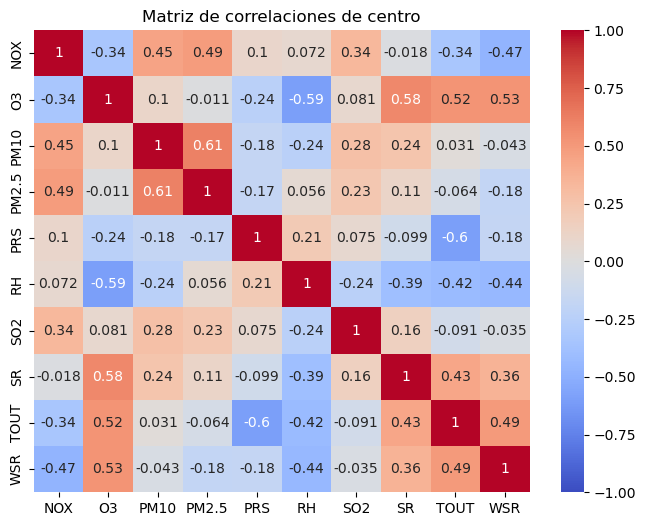

In [36]:
# Matriz de correlaciones para el DataFrame suroeste2 (visualización con imagen)
corr_matrix = centro.drop(columns=['date', "CO"]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de correlaciones de centro")
plt.show()

## Paso 1 - PCA

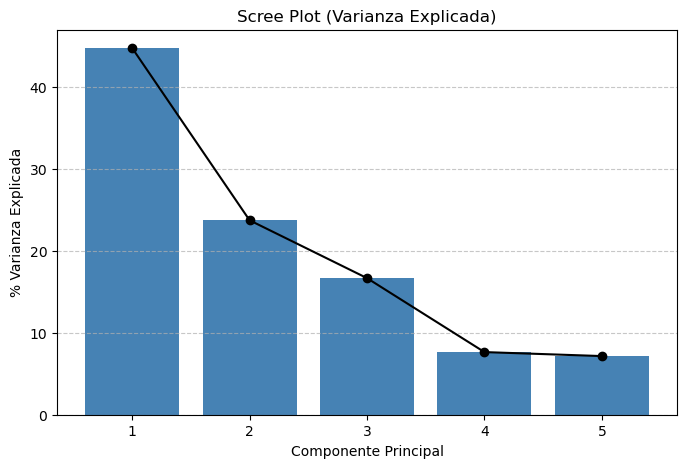

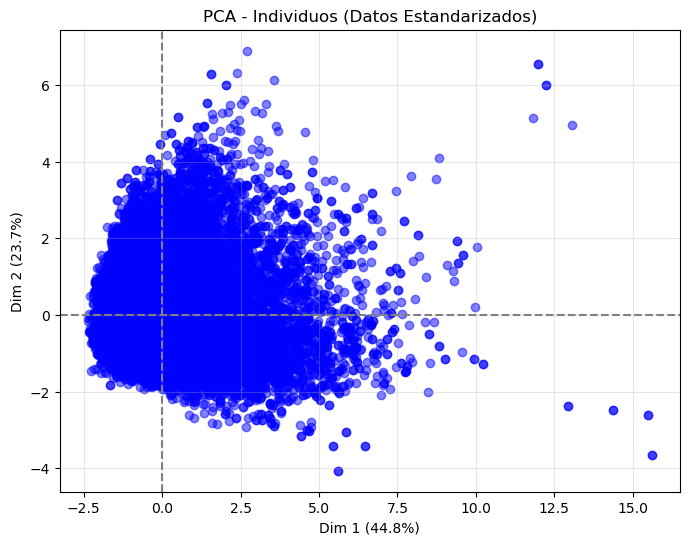

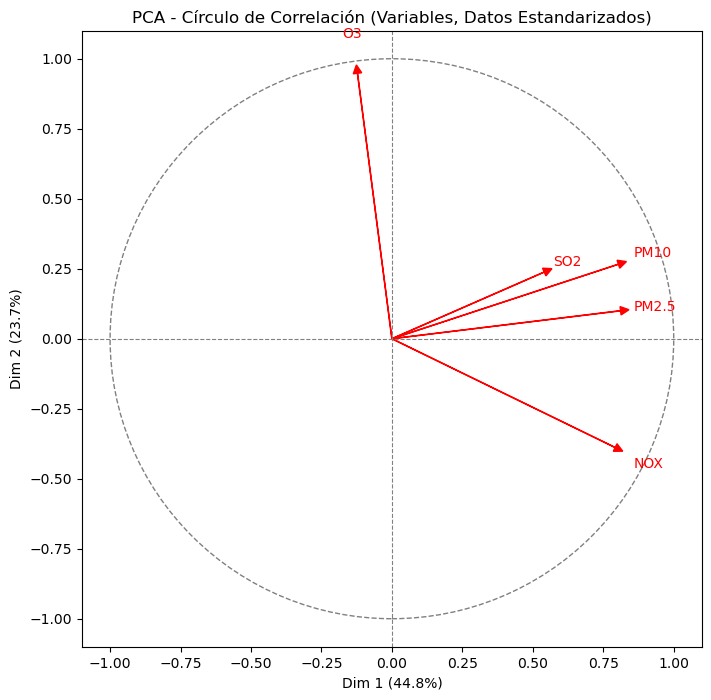

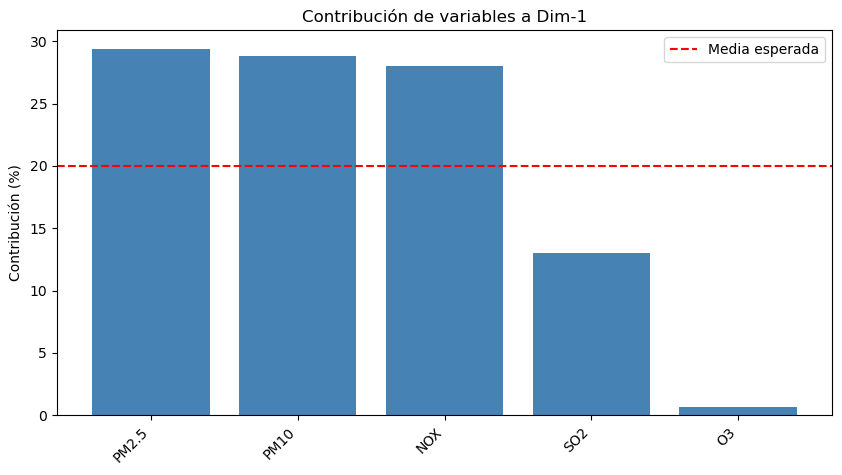

In [37]:
# --- 1. Preparación de datos y estandarización ---
# Estandarizar los datos (media=0, var=1)
scaler = StandardScaler()
datos_std = scaler.fit_transform(datos)

# --- 2. PCA (ahora con datos estandarizados) ---
pca = PCA()
pca_ind = pca.fit_transform(datos_std)

# --- 3. Scree Plot (Varianza explicada) ---
plt.figure(figsize=(8, 5))
varianza_expl = pca.explained_variance_ratio_ * 100
plt.bar(range(1, len(varianza_expl) + 1), varianza_expl, color='steelblue')
plt.plot(range(1, len(varianza_expl) + 1), varianza_expl, marker='o', color='black')
plt.title('Scree Plot (Varianza Explicada)')
plt.xlabel('Componente Principal')
plt.ylabel('% Varianza Explicada')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 4. Gráfica de Individuos ---
plt.figure(figsize=(8, 6))
plt.scatter(pca_ind[:, 0], pca_ind[:, 1], c='blue', alpha=0.5)
plt.xlabel(f'Dim 1 ({varianza_expl[0]:.1f}%)')
plt.ylabel(f'Dim 2 ({varianza_expl[1]:.1f}%)')
plt.title('PCA - Individuos (Datos Estandarizados)')
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. Gráfica de Variables (Círculo de correlación) ---
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
features = datos.columns

plt.figure(figsize=(8, 8))
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], 
              head_width=0.03, head_length=0.03, color='red')
    plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, 
             color='red', ha='center', va='center')

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel(f'Dim 1 ({varianza_expl[0]:.1f}%)')
plt.ylabel(f'Dim 2 ({varianza_expl[1]:.1f}%)')
plt.title('PCA - Círculo de Correlación (Variables, Datos Estandarizados)')
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(False)
plt.show()

# --- 6. Contribución de variables a la Dim-1 ---
contribs = (loadings[:, 0]**2)
contribs = 100 * contribs / contribs.sum()
indices_ordenados = np.argsort(contribs)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(features[indices_ordenados], contribs[indices_ordenados], color='steelblue')
plt.axhline(100/len(features), color='r', linestyle='--', label='Media esperada')
plt.title('Contribución de variables a Dim-1')
plt.ylabel('Contribución (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

## Paso 2 - Agrupación

In [38]:
# Estandarizar columnas relevantes en 'centro'
centro["PM10_std"] = (centro["PM10"] - centro["PM10"].mean()) / centro["PM10"].std()
centro["PM2.5_std"] = (centro["PM2.5"] - centro["PM2.5"].mean()) / centro["PM2.5"].std()
centro["NOX_std"] = (centro["NOX"] - centro["NOX"].mean()) / centro["NOX"].std()
centro["SO2_std"] = (centro["SO2"] - centro["SO2"].mean()) / centro["SO2"].std()
centro["O3_std"] = (centro["O3"] - centro["O3"].mean()) / centro["O3"].std()

# Crear los grupos Y en 'centro', incluyendo la fecha de captura
centro["Y_1"] = centro[["SO2_std", "PM2.5_std", "PM10_std"]].mean(axis=1)

# Incluye la columna "date" en el DataFrame resultado
centro_Y = centro[["date", "Y_1", "O3","NOX", "TOUT", "RH", "SR", "PRS", "WSR"]]


#diatio
df_Centro_diario = centro_Y.copy()
df_Centro_diario['date'] = pd.to_datetime(df_Centro_diario['date'])
df_Centro_diario = df_Centro_diario.set_index('date')
df_Centro_diario = df_Centro_diario.resample("D").mean()


#semanal
df_Centro_semanal = centro_Y.copy()
df_Centro_semanal['date'] = pd.to_datetime(df_Centro_semanal['date'])
df_Centro_semanal = df_Centro_semanal.set_index('date')
df_Centro_semanal = df_Centro_semanal.resample("W").mean()

In [39]:
df_Centro_diario.describe().T

,count,mean,std,min,25%,50%,75%,max
Y_1,1096.0,0.009622,0.562503,-1.103776,-0.405779,-0.067045,0.354974,2.776222
O3,1096.0,27.975467,10.116262,1.197917,21.197917,27.331458,34.125000,64.340417
NOX,1096.0,25.810768,14.805501,7.333333,16.049479,21.285417,31.036458,146.579167
TOUT,1096.0,22.893602,6.225992,0.430417,18.773854,24.186042,27.781667,36.752500
RH,1096.0,54.579522,15.842461,7.000000,44.208333,54.187500,65.125000,93.270833
SR,1096.0,0.186090,0.085317,0.000000,0.135313,0.187500,0.246458,0.625417
PRS,1096.0,711.398865,3.326121,701.658333,709.221875,711.122917,713.310417,722.158333
WSR,1096.0,7.744530,2.284238,2.366667,5.989583,7.702083,9.375000,18.275000


In [40]:
df_Centro_semanal.describe().T

,count,mean,std,min,25%,50%,75%,max
Y_1,158.0,0.009056,0.423325,-0.883874,-0.309705,-0.017629,0.316859,1.263884
O3,158.0,27.970304,7.998976,8.866071,23.747024,26.866071,32.534226,49.744048
NOX,158.0,25.838429,10.967943,12.100595,16.815030,22.350446,33.220908,61.632738
TOUT,158.0,22.882984,5.605031,8.382381,18.658899,23.701369,27.656488,32.866250
RH,158.0,54.283940,11.823859,18.729167,46.844494,53.845238,63.630208,87.383929
SR,158.0,0.185728,0.068979,0.021726,0.128884,0.187083,0.230000,0.365238
PRS,158.0,711.391583,2.298056,706.201786,709.793155,711.313839,712.859524,717.163690
WSR,158.0,7.738885,1.821683,3.688095,6.334524,7.730208,9.195461,12.592857


## Paso 3 - ACF

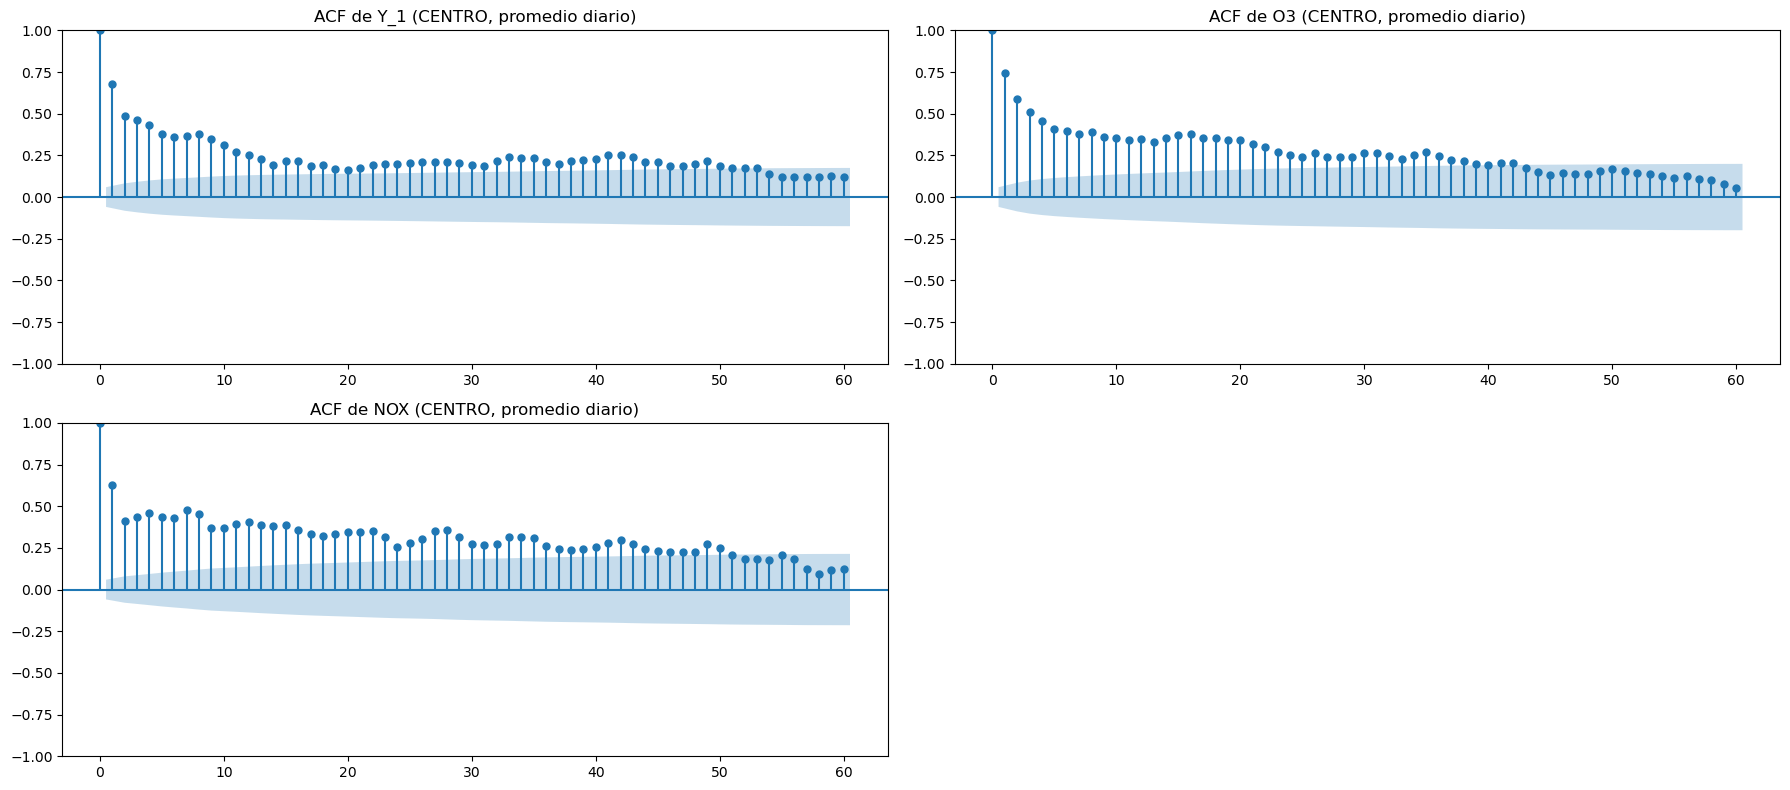

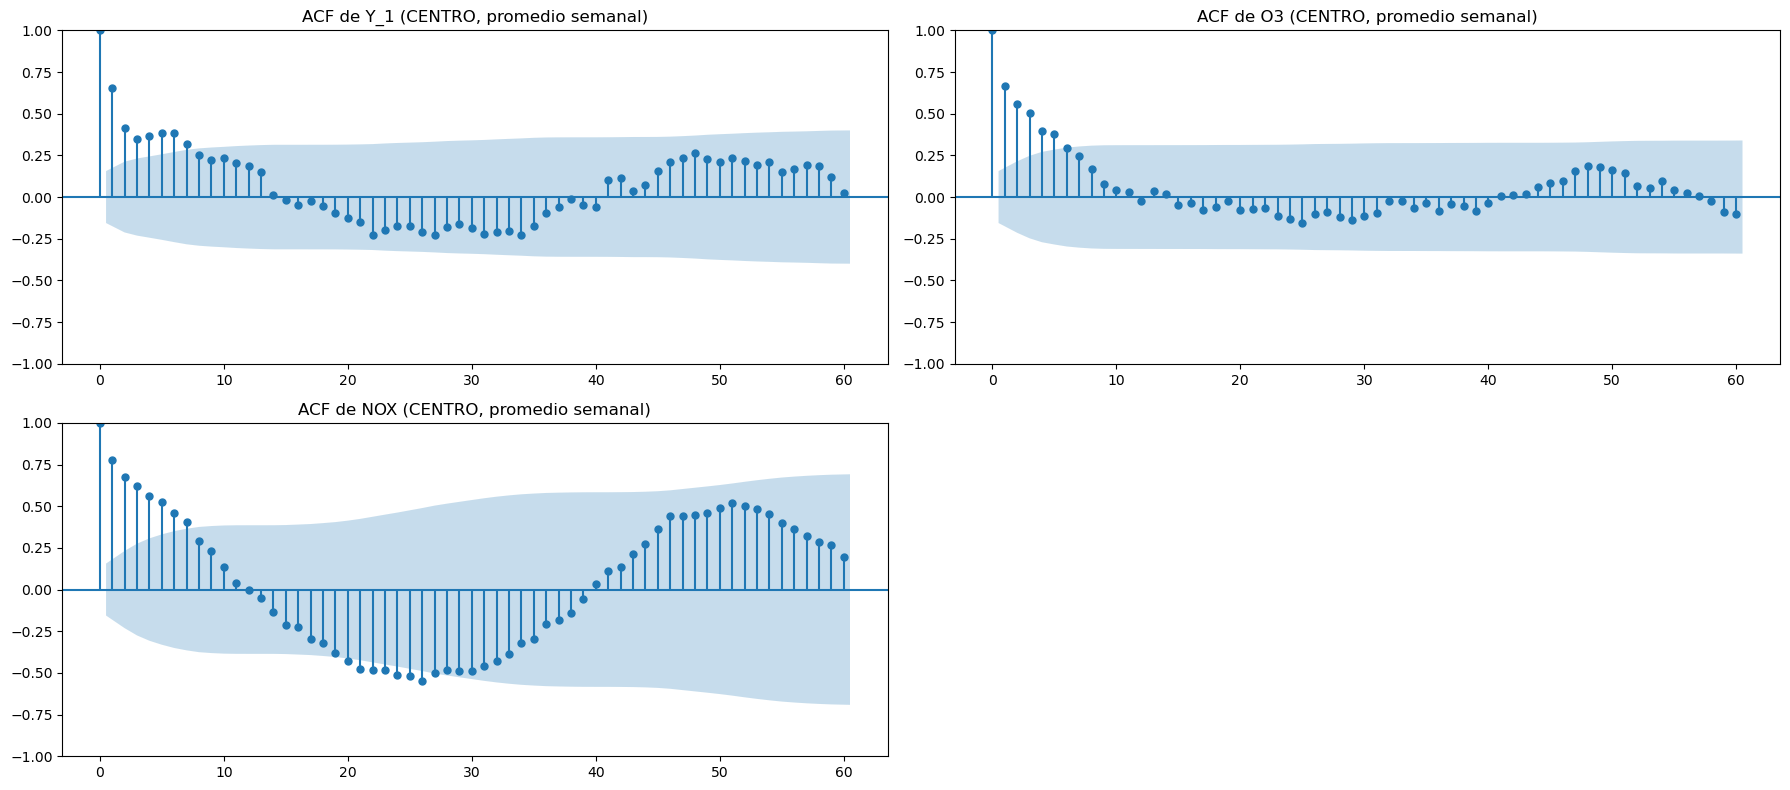

In [41]:
variables_analizar = ["Y_1", "O3", "NOX"]

# --- ACF diario ---
nrows, ncols = 2, 2  # 2 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()  # aplanar para indexado sencillo

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_Centro_diario.columns:
        serie = df_Centro_diario[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)
        ax.set_title(f"ACF de {var} (CENTRO, promedio diario)")
    else:
        ax.set_visible(False)

# Oculta ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# --- ACF semanal ---
nrows, ncols = 2, 2  # 2 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_Centro_semanal.columns:
        serie = df_Centro_semanal[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)  # lags puede ser menor porque hay menos datos semanales
        ax.set_title(f"ACF de {var} (CENTRO, promedio semanal)")
    else:
        ax.set_visible(False)

for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## Paso 4 - Arimax

### Y_1 (PM10, PM2.5, SO2)

In [ ]:
out = fit_best_sarimax(df_Centro_diario, df_Centro_semanal, "Y_1", y_transform=None, inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    y_1_centro = best["results"].summary()
    print(y_1_centro)

plot_diagnostics(best)

### O3 

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 5390.030040332568
MAE: 18.345486585886675
RMSE: 19.578818556020522
R2: -3.018076539948405
LjungBox_p: 0.4569584040170126
JarqueBera_p: 4.386387220150058e-08
best_order: (1, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
1       RH -3.187379   3.187379  3.310461e-28
2       SR  2.907118   2.907118  3.064003e-18
3      PRS  1.396258   1.396258  8.765435e-05
0     TOUT  0.917248   0.917248  1.331974e-01
4      WSR -0.479029   0.479029  8.417217e-02
                               SARIMAX Results                                
Dep. Variable:                     O3   No. Observations:                  876
Model:               SARIMAX(1, 1, 5)   Log Likelihood               -2683.015
Date:                Sat, 06 Dec 2025   AIC                           5390.030
Time:                        20:57:22   BIC                           5447.238
Sample:                    01-01-2022   HQIC                          5411.921
                         - 05-25-2

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


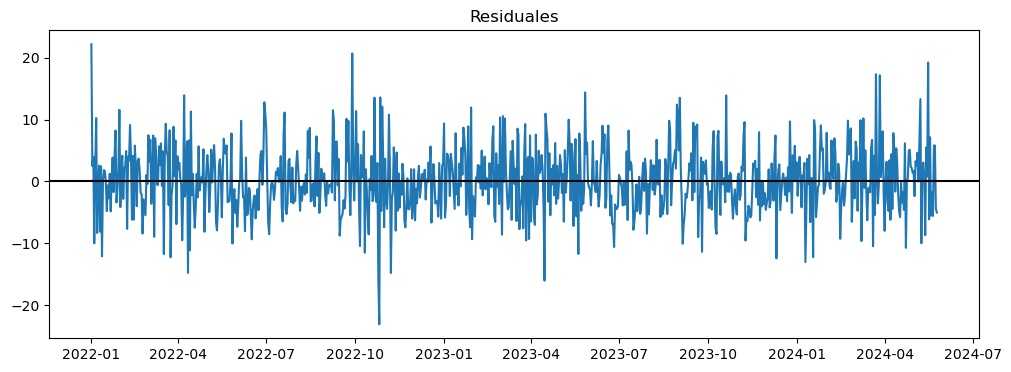

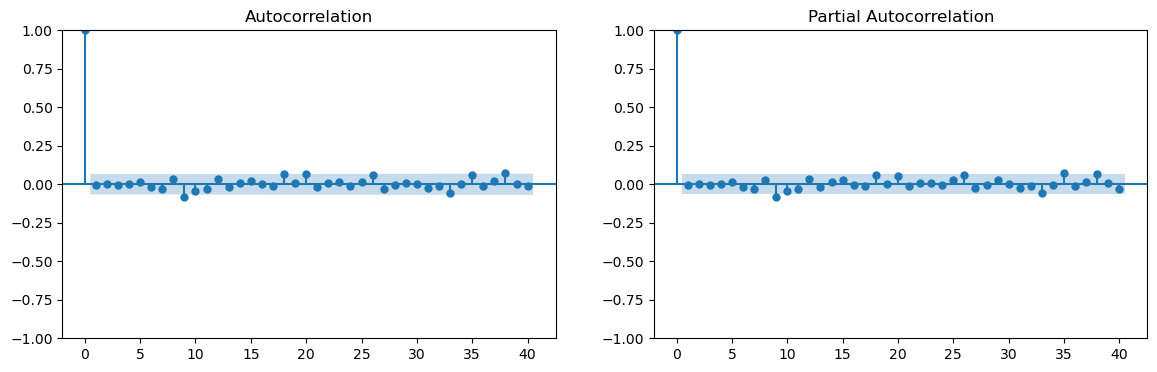

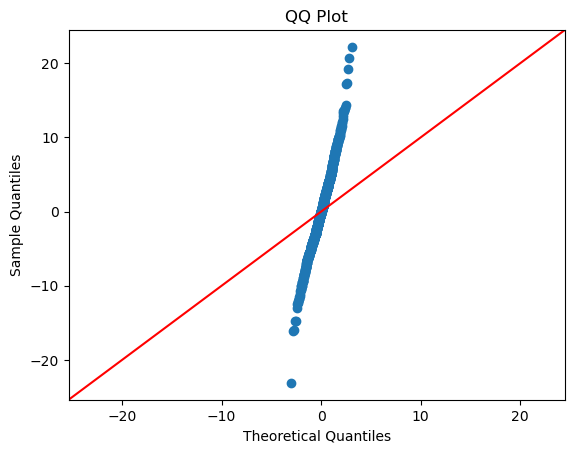

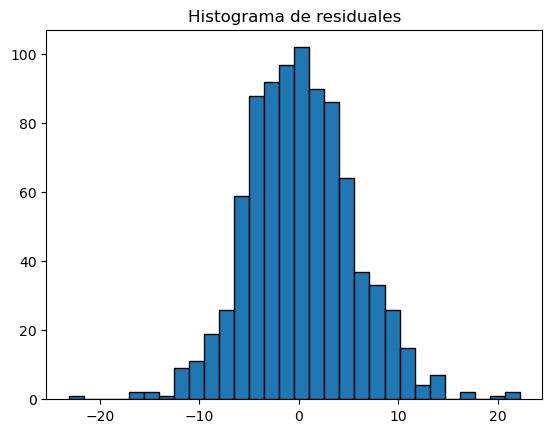

In [ ]:
out = fit_best_sarimax(df_Centro_diario, df_Centro_semanal, "O3", y_transform=None,inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    o3_centro = best["results"].summary()
    print(o3_centro)

plot_diagnostics(best)

### NOX

In [ ]:
out = fit_best_sarimax(df_Centro_diario, df_Centro_semanal, "NOX",y_transform=None, inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    nox_centro = best["results"].summary()
    print(nox_centro)

plot_diagnostics(best)

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

KeyboardInterrupt: 

# SUROESTE2

## data

In [28]:
# Cargar datos
suroeste2 = pd.read_csv("df_SUROESTE2_22_25.csv")
cols_contaminantes = ["PM10", "PM2.5", "O3", "NOX", "SO2"]
datos = suroeste2[cols_contaminantes]

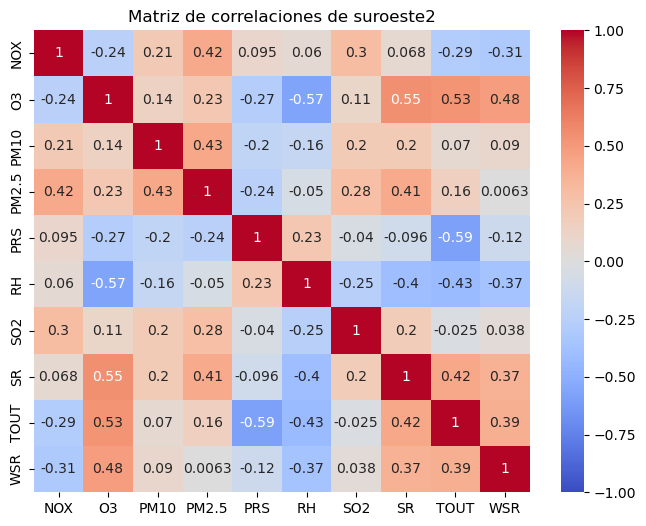

In [29]:
# Matriz de correlaciones para el DataFrame suroeste2 (visualización con imagen)
corr_matrix = suroeste2.drop(columns=['date', "CO"]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de correlaciones de suroeste2")
plt.show()


## Paso 1 - PCA

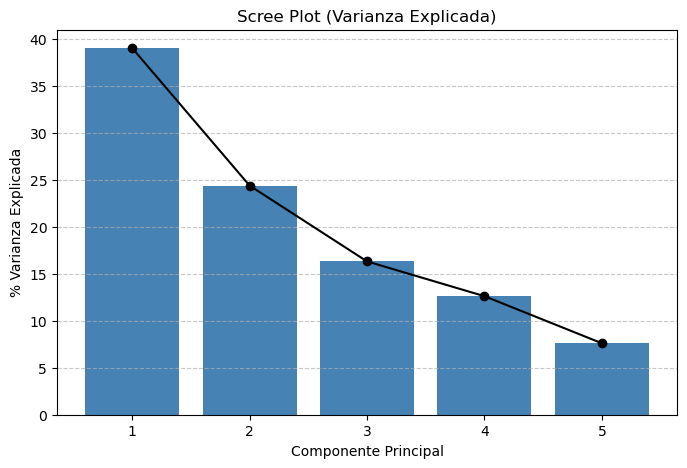

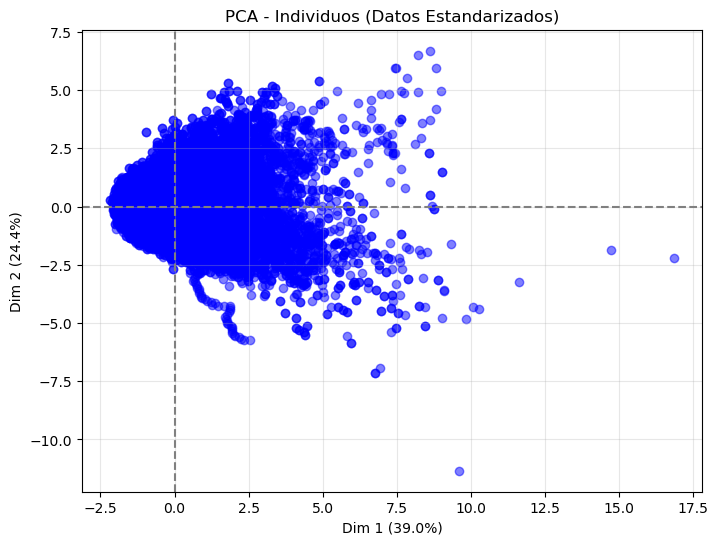

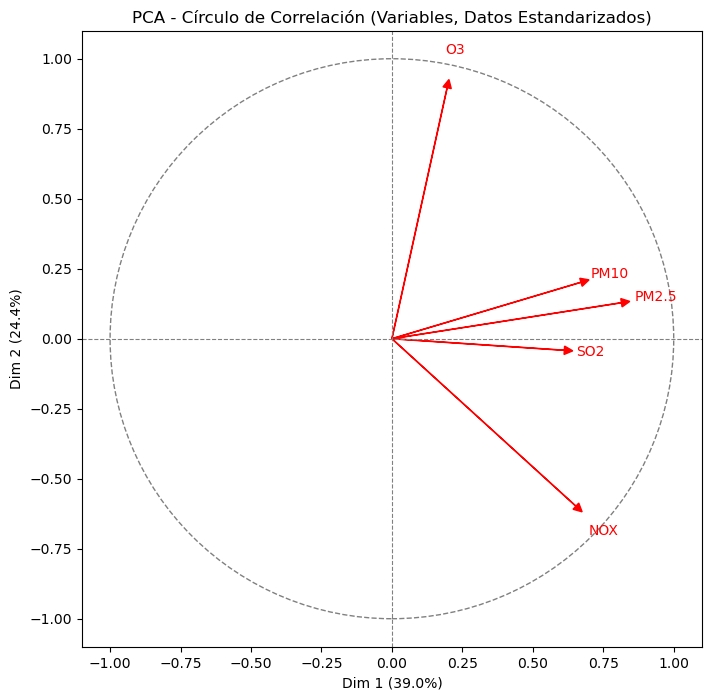

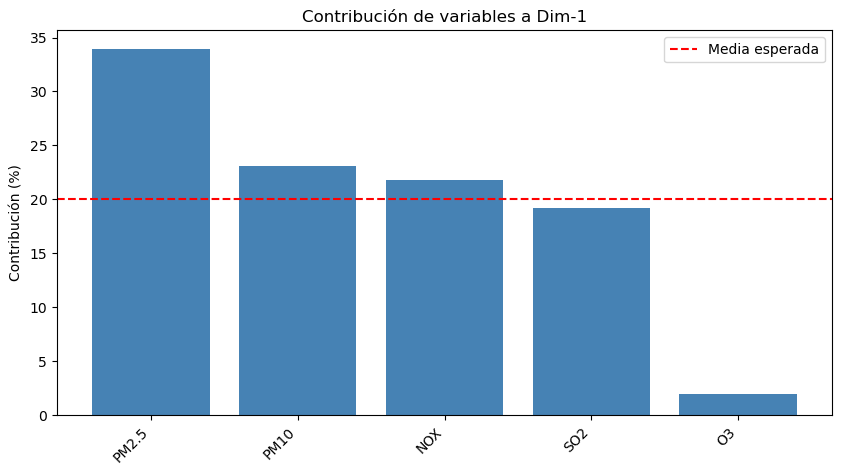

In [107]:
# --- 1. Preparación de datos y estandarización ---
# Estandarizar los datos (media=0, var=1)
scaler = StandardScaler()
datos_std = scaler.fit_transform(datos)

# --- 2. PCA (ahora con datos estandarizados) ---
pca = PCA()
pca_ind = pca.fit_transform(datos_std)

# --- 3. Scree Plot (Varianza explicada) ---
plt.figure(figsize=(8, 5))
varianza_expl = pca.explained_variance_ratio_ * 100
plt.bar(range(1, len(varianza_expl) + 1), varianza_expl, color='steelblue')
plt.plot(range(1, len(varianza_expl) + 1), varianza_expl, marker='o', color='black')
plt.title('Scree Plot (Varianza Explicada)')
plt.xlabel('Componente Principal')
plt.ylabel('% Varianza Explicada')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 4. Gráfica de Individuos ---
plt.figure(figsize=(8, 6))
plt.scatter(pca_ind[:, 0], pca_ind[:, 1], c='blue', alpha=0.5)
plt.xlabel(f'Dim 1 ({varianza_expl[0]:.1f}%)')
plt.ylabel(f'Dim 2 ({varianza_expl[1]:.1f}%)')
plt.title('PCA - Individuos (Datos Estandarizados)')
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. Gráfica de Variables (Círculo de correlación) ---
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
features = datos.columns

plt.figure(figsize=(8, 8))
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], 
              head_width=0.03, head_length=0.03, color='red')
    plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, 
             color='red', ha='center', va='center')

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel(f'Dim 1 ({varianza_expl[0]:.1f}%)')
plt.ylabel(f'Dim 2 ({varianza_expl[1]:.1f}%)')
plt.title('PCA - Círculo de Correlación (Variables, Datos Estandarizados)')
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(False)
plt.show()

# --- 6. Contribución de variables a la Dim-1 ---
contribs = (loadings[:, 0]**2)
contribs = 100 * contribs / contribs.sum()
indices_ordenados = np.argsort(contribs)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(features[indices_ordenados], contribs[indices_ordenados], color='steelblue')
plt.axhline(100/len(features), color='r', linestyle='--', label='Media esperada')
plt.title('Contribución de variables a Dim-1')
plt.ylabel('Contribución (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

## Paso 2 - Agrupación

In [108]:
# Estandarizar columnas relevantes 
suroeste2["PM10_std"] = (suroeste2["PM10"] - suroeste2["PM10"].mean()) / suroeste2["PM10"].std()
suroeste2["PM2.5_std"] = (suroeste2["PM2.5"] - suroeste2["PM2.5"].mean()) / suroeste2["PM2.5"].std()
suroeste2["SO2_std"] = (suroeste2["SO2"] - suroeste2["SO2"].mean()) / suroeste2["SO2"].std()


suroeste2["Y_1"] = suroeste2[["SO2_std", "PM2.5_std", "PM10_std"]].mean(axis=1)

# Incluye la columna "date" en el DataFrame resultado
suroeste2_Y = suroeste2[["date", "Y_1", "O3","NOX", "TOUT", "RH", "SR", "PRS", "WSR"]]


#diario
df_Suroeste2_diario = suroeste2_Y.copy()
df_Suroeste2_diario['date'] = pd.to_datetime(df_Suroeste2_diario['date'])
df_Suroeste2_diario = df_Suroeste2_diario.set_index('date')
df_Suroeste2_diario = df_Suroeste2_diario.resample("D").mean()


#semanal
df_Suroeste2_semanal = suroeste2_Y.copy()
df_Suroeste2_semanal['date'] = pd.to_datetime(df_Suroeste2_semanal['date'])
df_Suroeste2_semanal = df_Suroeste2_semanal.set_index('date')
df_Suroeste2_semanal = df_Suroeste2_semanal.resample("W").mean()

In [109]:
df_Suroeste2_diario.describe().T

,count,mean,std,min,25%,50%,75%,max
Y_1,1096.0,0.011535,0.476639,-0.915632,-0.320179,-0.073741,0.272919,2.812371
O3,1096.0,27.801600,11.708109,1.237500,19.791667,26.604167,34.593750,96.831250
NOX,1096.0,25.110452,13.249901,5.950000,16.859375,21.427083,29.527083,149.542917
TOUT,1096.0,22.986086,6.334514,0.060833,18.744062,24.194792,27.988958,35.881667
RH,1096.0,53.842456,15.683263,7.250000,44.281250,53.583333,64.291667,89.680417
SR,1096.0,0.165449,0.067424,0.000000,0.121771,0.168750,0.220000,0.284167
PRS,1096.0,713.846055,1.440276,709.441667,712.919792,713.754167,714.713542,718.541667
WSR,1096.0,10.414521,2.805312,3.691667,8.260417,10.373958,12.410417,20.525000


In [110]:
df_Suroeste2_semanal.describe().T

,count,mean,std,min,25%,50%,75%,max
Y_1,158.0,0.010186,0.344408,-0.725491,-0.225077,-0.045734,0.244958,1.404293
O3,158.0,27.828509,9.366418,7.527738,22.431548,27.142857,32.477679,55.125000
NOX,158.0,25.061559,9.758522,11.691071,17.774628,22.083333,30.711607,63.876190
TOUT,158.0,22.970968,5.722750,8.628095,18.654896,23.786280,27.892024,33.241845
RH,158.0,53.553426,11.739657,19.500000,46.508929,52.842262,62.497768,85.261905
SR,158.0,0.165249,0.054522,0.047024,0.120960,0.165804,0.209658,0.269048
PRS,158.0,713.843013,1.000031,711.463095,713.160045,713.778869,714.459747,716.234431
WSR,158.0,10.412042,2.057046,6.522619,8.815774,10.452976,11.986458,16.478571


## Paso 3 - ACF

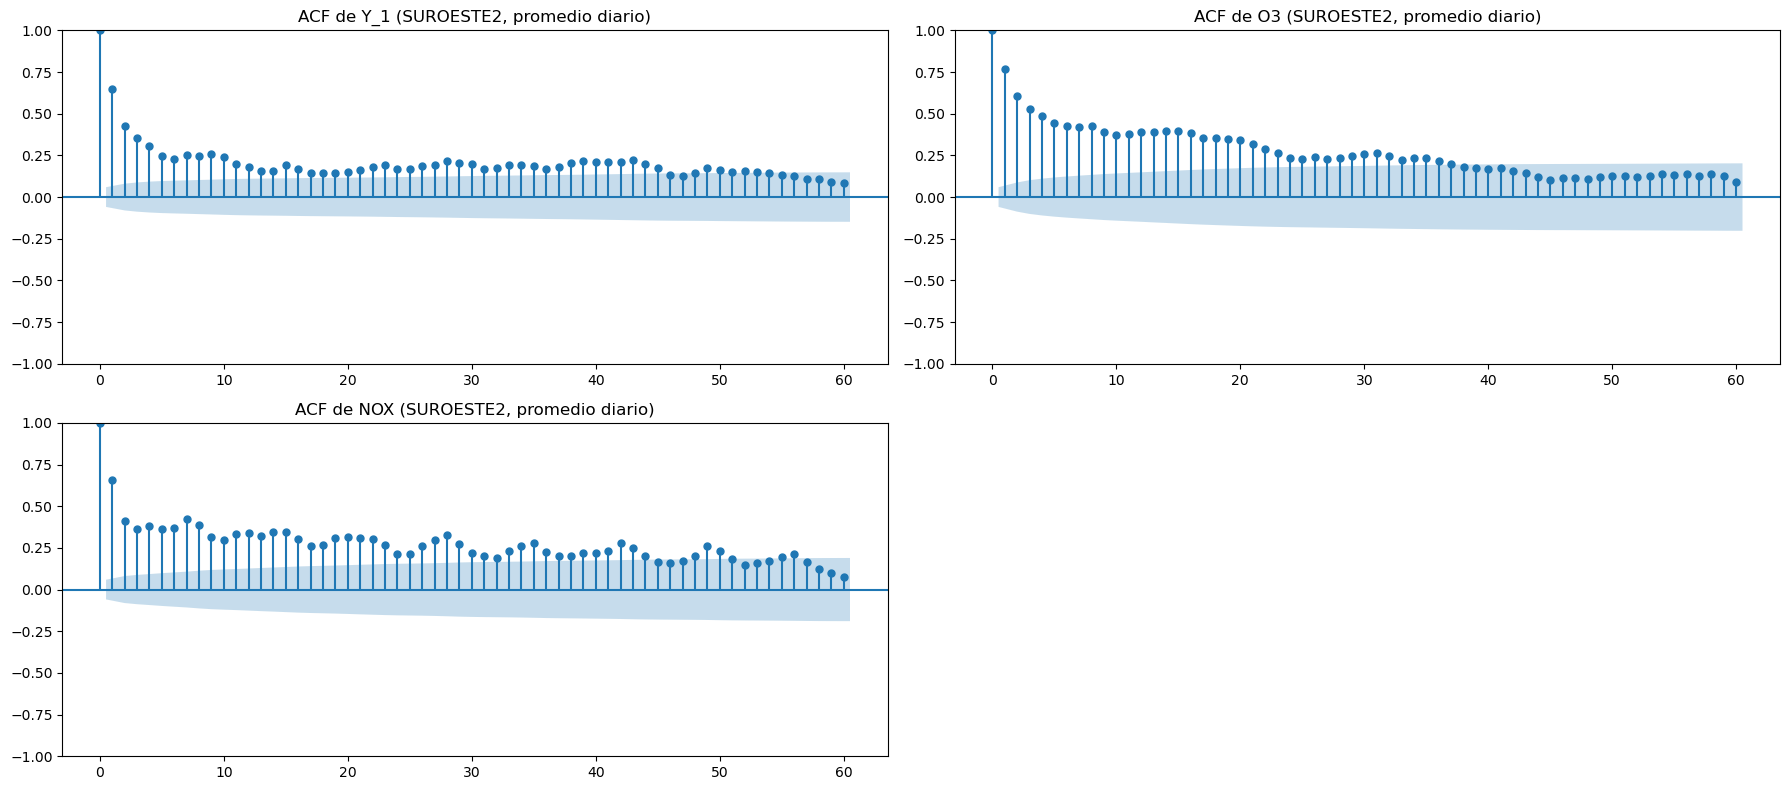

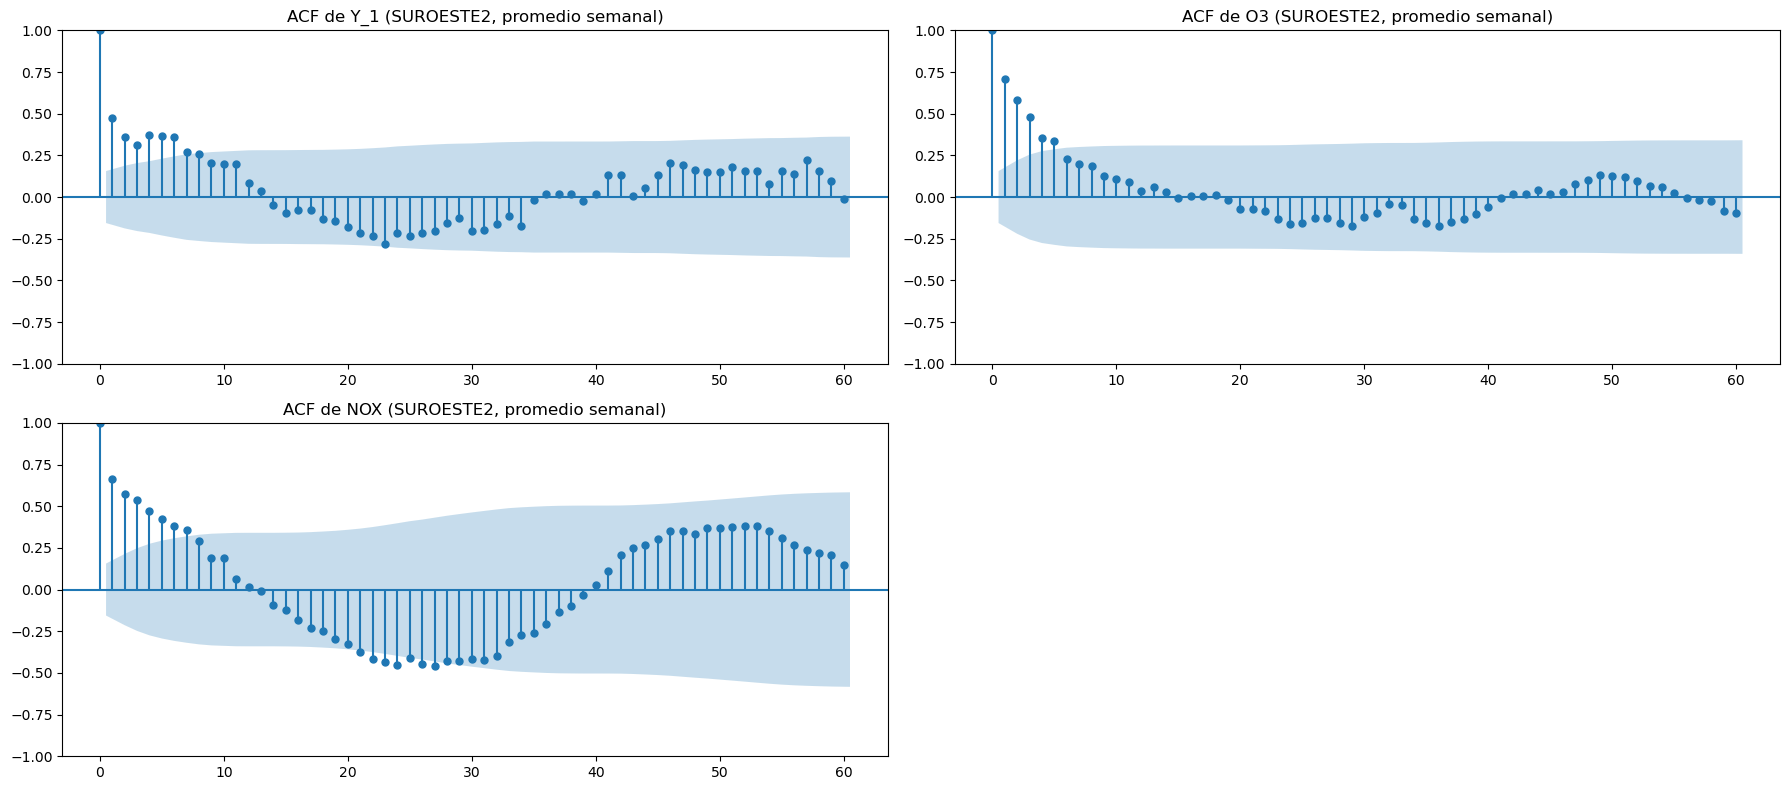

In [111]:
variables_analizar = ["Y_1", "O3", "NOX"]

# --- ACF diario ---
nrows, ncols = 2, 2  # 2 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()  # aplanar para indexado sencillo

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_Suroeste2_diario.columns:
        serie = df_Suroeste2_diario[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)
        ax.set_title(f"ACF de {var} (SUROESTE2, promedio diario)")
    else:
        ax.set_visible(False)

# Oculta ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# --- ACF semanal ---
nrows, ncols = 2, 2  # 2 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_Suroeste2_semanal.columns:
        serie = df_Suroeste2_semanal[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)  # lags puede ser menor porque hay menos datos semanales
        ax.set_title(f"ACF de {var} (SUROESTE2, promedio semanal)")
    else:
        ax.set_visible(False)

for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Paso 4 - Arimax

### Y_1 (PM10, PM2.5, SO2)

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Semanal
AIC: 13.720551433314965
MAE: 0.30887120268987966
RMSE: 0.3546781686018376
R2: -0.6893502751228391
LjungBox_p: 0.95293562090433
JarqueBera_p: 6.493121035808079e-06
best_order: (4, 0, 1)
  Variable      Coef  AbsImpact    Pvalue
3      PRS -0.168239   0.168239  0.000010
0     TOUT -0.114039   0.114039  0.072929
1       RH -0.105485   0.105485  0.000089
4      WSR -0.059648   0.059648  0.075639
2       SR  0.032662   0.032662  0.592253
                               SARIMAX Results                                
Dep. Variable:                    Y_1   No. Observations:                  126
Model:               SARIMAX(4, 0, 1)   Log Likelihood                   4.140
Date:                Sat, 06 Dec 2025   AIC                             13.721
Time:                        20:20:48   BIC                             44.565
Sample:                    01-02-2022   HQIC                            26.249
                         - 05-26-2024                   

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


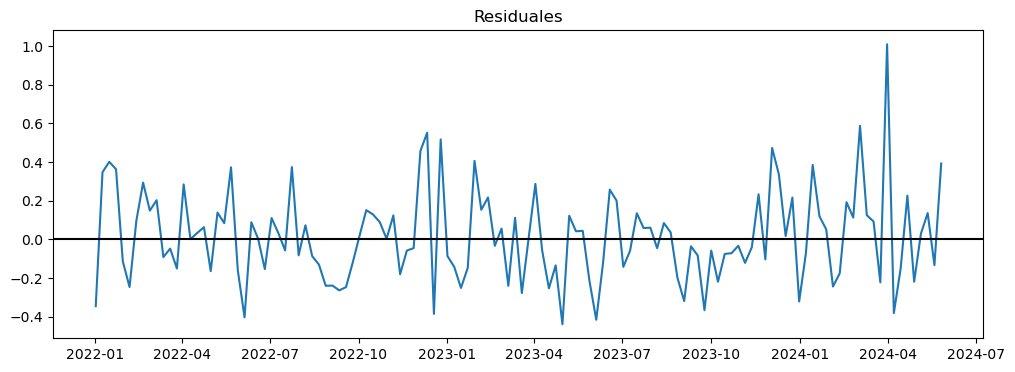

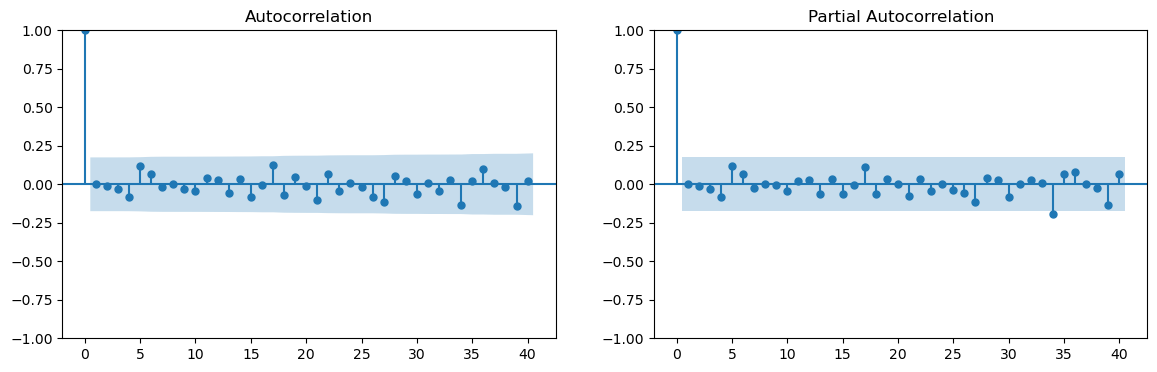

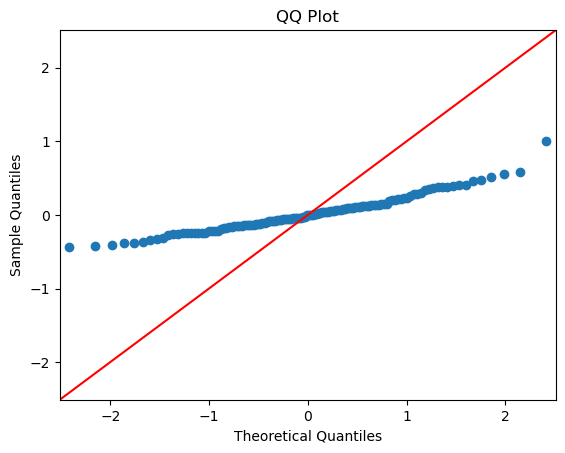

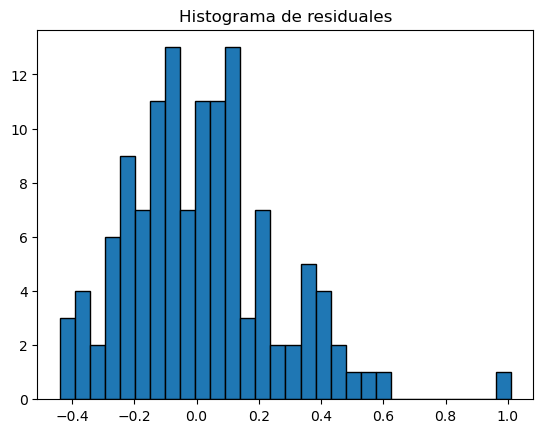

In [112]:
out = fit_best_sarimax(df_Suroeste2_diario, df_Suroeste2_semanal, "Y_1", y_transform=None, inverse_transform=None)

for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    y_1_suroeste = best["results"].summary()
    print(y_1_suroeste)

plot_diagnostics(best)

### O3

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 5532.007006097372
MAE: 21.31253248923607
RMSE: 22.954801377623617
R2: -2.380310084580487
LjungBox_p: 0.10213581279256484
JarqueBera_p: 7.821835894134545e-16
best_order: (1, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
1       RH -3.916581   3.916581  1.954678e-28
2       SR  2.190812   2.190812  1.674968e-17
0     TOUT  2.131586   2.131586  2.790511e-03
3      PRS  1.846837   1.846837  6.166537e-06
4      WSR -0.673355   0.673355  8.019242e-03
                               SARIMAX Results                                
Dep. Variable:                     O3   No. Observations:                  876
Model:               SARIMAX(1, 1, 5)   Log Likelihood               -2754.004
Date:                Sat, 06 Dec 2025   AIC                           5532.007
Time:                        20:21:31   BIC                           5589.215
Sample:                    01-01-2022   HQIC                          5553.898
                         - 05-25-2

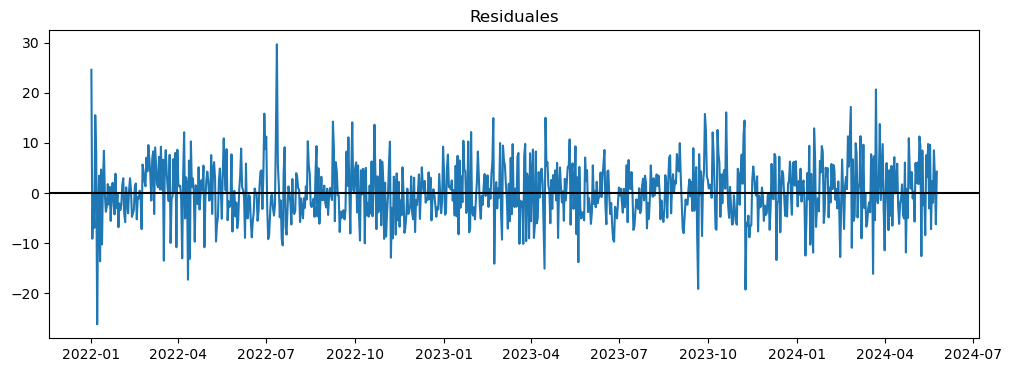

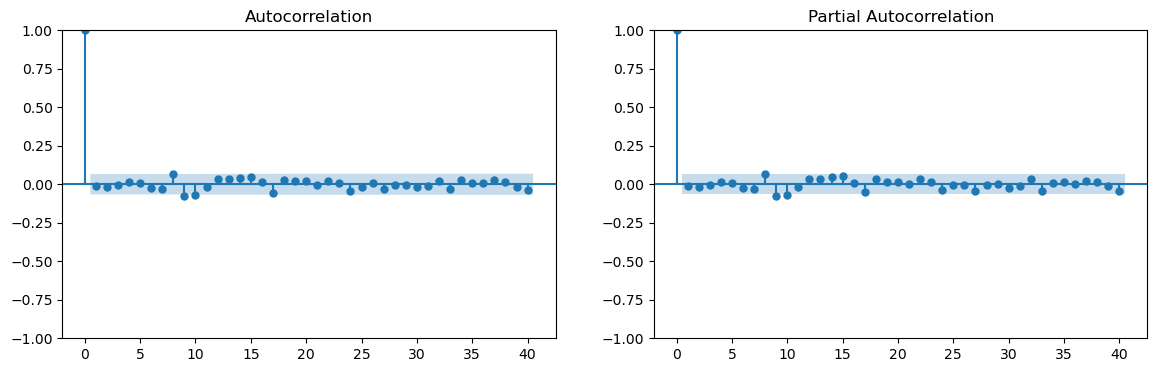

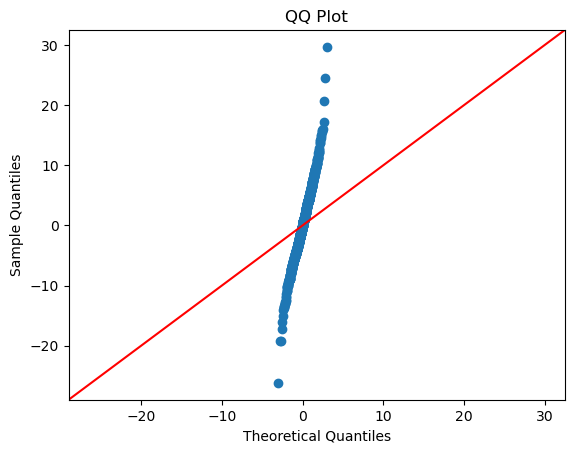

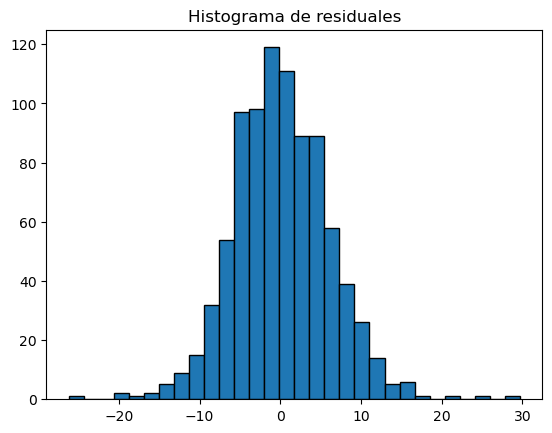

In [113]:
out = fit_best_sarimax(df_Suroeste2_diario, df_Suroeste2_semanal, "O3", y_transform=None, inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    o3_suroeste = best["results"].summary()
    print(o3_suroeste)

plot_diagnostics(best)

### NOX

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Semanal
AIC: 792.8029621523434
MAE: 5.689776443246782
RMSE: 6.839679126898137
R2: 0.33217477006025864
LjungBox_p: 0.6299548817810707
JarqueBera_p: 1.6293233535410204e-164
best_order: (2, 1, 5)
  Variable      Coef  AbsImpact    Pvalue
4      WSR -3.812255   3.812255  0.000322
0     TOUT -3.707492   3.707492  0.003741
2       SR -2.063997   2.063997  0.060892
1       RH -1.605946   1.605946  0.165982
3      PRS -0.678173   0.678173  0.609093
                               SARIMAX Results                                
Dep. Variable:                    NOX   No. Observations:                  126
Model:               SARIMAX(2, 1, 5)   Log Likelihood                -383.401
Date:                Sat, 06 Dec 2025   AIC                            792.803
Time:                        20:22:16   BIC                            828.932
Sample:                    01-02-2022   HQIC                           807.474
                         - 05-26-2024                   

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


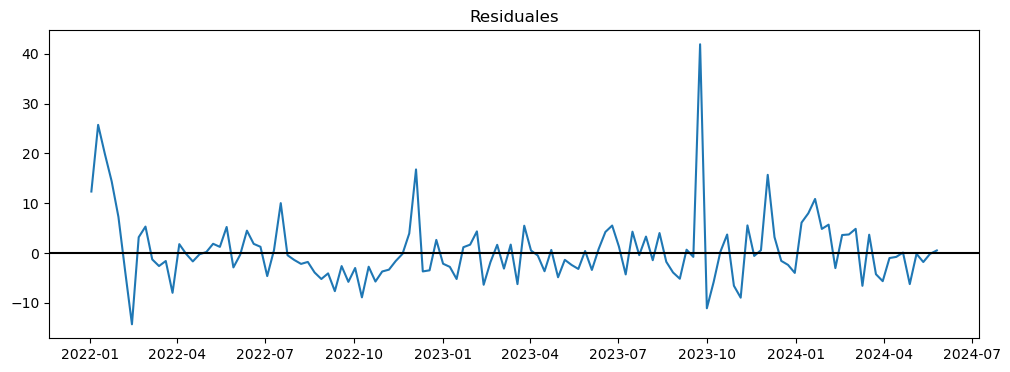

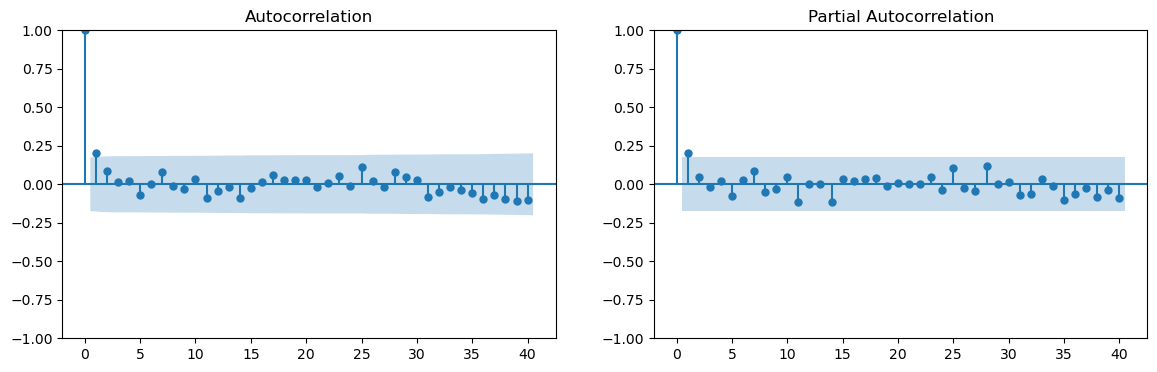

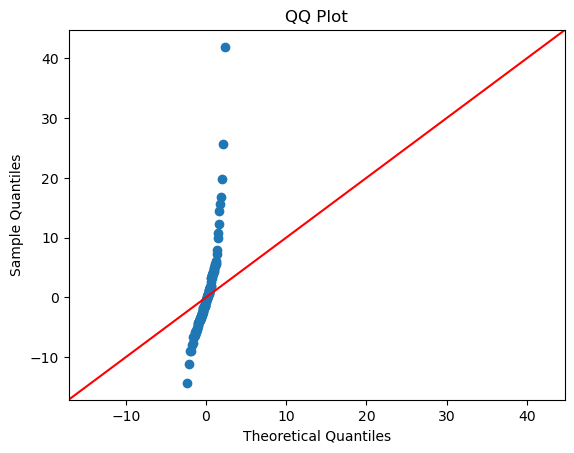

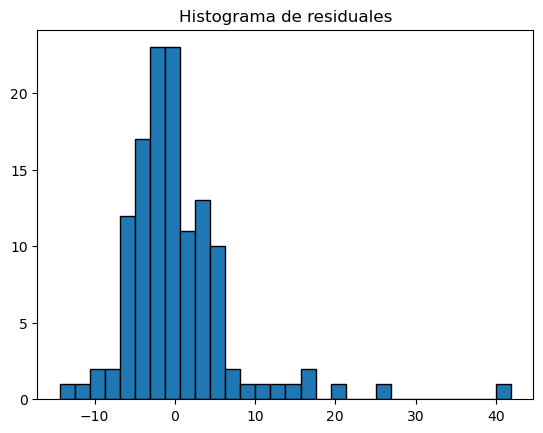

In [114]:
out = fit_best_sarimax(df_Suroeste2_diario, df_Suroeste2_semanal, "NOX", y_transform=None, inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    nox_suroeste = best["results"].summary()
    print(nox_suroeste)

plot_diagnostics(best)

# NORTE

## data

In [30]:
# Cargar datos
norte2 = pd.read_csv("df_NORTE2_22_25.csv")
cols_contaminantes = ["PM10", "PM2.5", "O3", "NOX", "SO2"]
datos = norte2[cols_contaminantes]

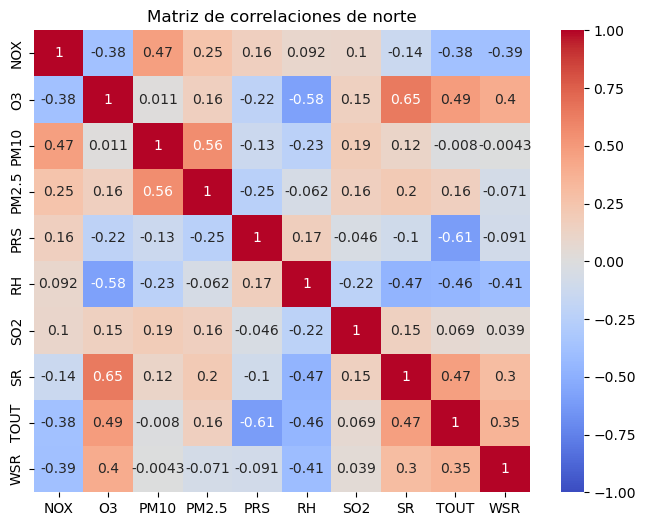

In [31]:
corr_matrix = norte2.drop(columns=['date',"CO"]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de correlaciones de norte")
plt.show()

## PASO 1 - PCA

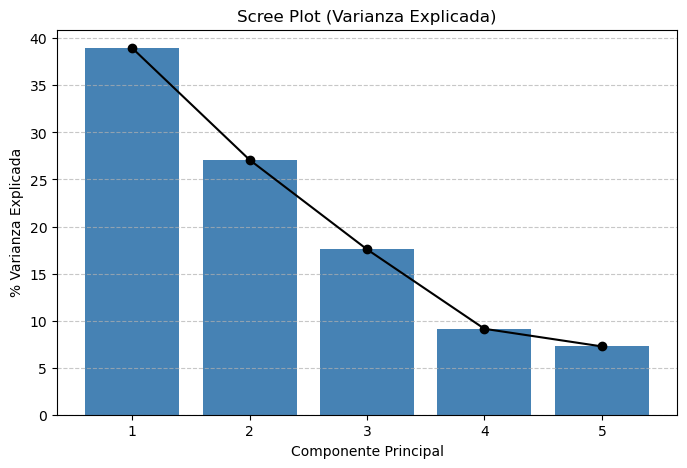

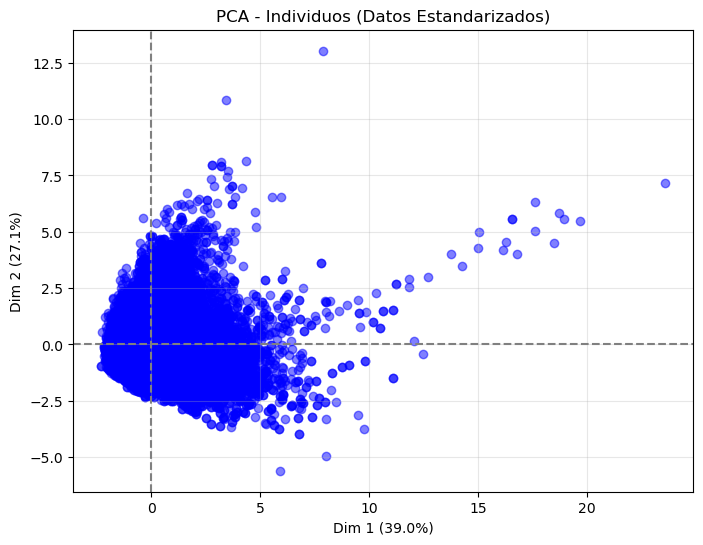

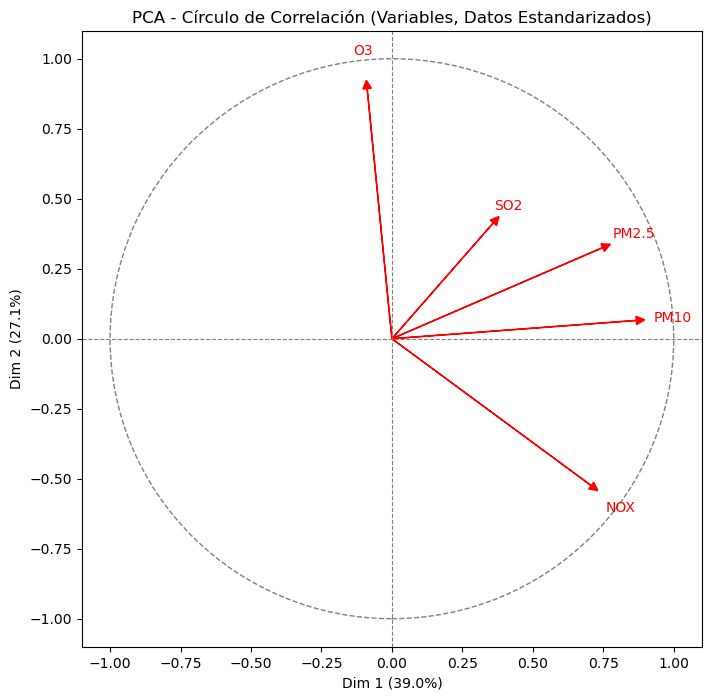

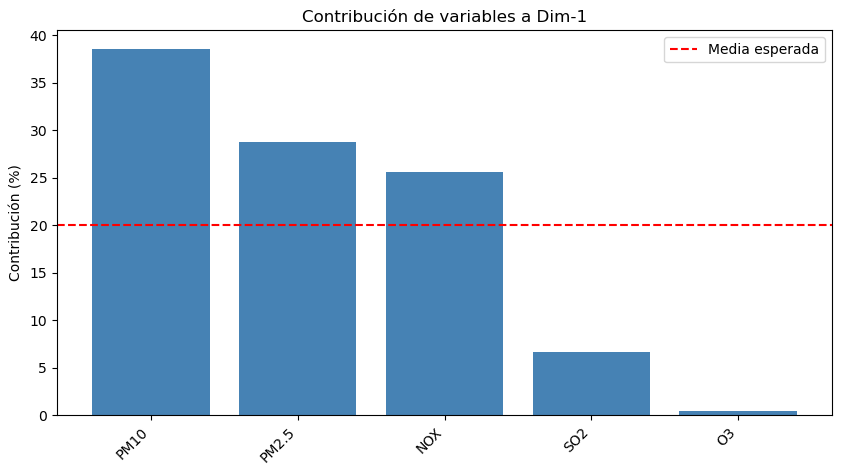

In [117]:
# --- 1. Preparación de datos y estandarización ---
# Estandarizar los datos (media=0, var=1)
scaler = StandardScaler()
datos_std = scaler.fit_transform(datos)

# --- 2. PCA (ahora con datos estandarizados) ---
pca = PCA()
pca_ind = pca.fit_transform(datos_std)

# --- 3. Scree Plot (Varianza explicada) ---
plt.figure(figsize=(8, 5))
varianza_expl = pca.explained_variance_ratio_ * 100
plt.bar(range(1, len(varianza_expl) + 1), varianza_expl, color='steelblue')
plt.plot(range(1, len(varianza_expl) + 1), varianza_expl, marker='o', color='black')
plt.title('Scree Plot (Varianza Explicada)')
plt.xlabel('Componente Principal')
plt.ylabel('% Varianza Explicada')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 4. Gráfica de Individuos ---
plt.figure(figsize=(8, 6))
plt.scatter(pca_ind[:, 0], pca_ind[:, 1], c='blue', alpha=0.5)
plt.xlabel(f'Dim 1 ({varianza_expl[0]:.1f}%)')
plt.ylabel(f'Dim 2 ({varianza_expl[1]:.1f}%)')
plt.title('PCA - Individuos (Datos Estandarizados)')
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. Gráfica de Variables (Círculo de correlación) ---
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
features = datos.columns

plt.figure(figsize=(8, 8))
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], 
              head_width=0.03, head_length=0.03, color='red')
    plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, 
             color='red', ha='center', va='center')

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel(f'Dim 1 ({varianza_expl[0]:.1f}%)')
plt.ylabel(f'Dim 2 ({varianza_expl[1]:.1f}%)')
plt.title('PCA - Círculo de Correlación (Variables, Datos Estandarizados)')
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(False)
plt.show()

# --- 6. Contribución de variables a la Dim-1 ---
contribs = (loadings[:, 0]**2)
contribs = 100 * contribs / contribs.sum()
indices_ordenados = np.argsort(contribs)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(features[indices_ordenados], contribs[indices_ordenados], color='steelblue')
plt.axhline(100/len(features), color='r', linestyle='--', label='Media esperada')
plt.title('Contribución de variables a Dim-1')
plt.ylabel('Contribución (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

## Paso 2 - Agrupación

In [118]:
# Estandarizar columnas relevantes en 'centro'
norte2["PM10_std"] = (norte2["PM10"] - norte2["PM10"].mean()) / norte2["PM10"].std()
norte2["PM2.5_std"] = (norte2["PM2.5"] - norte2["PM2.5"].mean()) / norte2["PM2.5"].std()
norte2["NOX_std"] = (norte2["NOX"] - norte2["NOX"].mean()) / norte2["NOX"].std()
norte2["SO2_std"] = (norte2["SO2"] - norte2["SO2"].mean()) / norte2["SO2"].std()
norte2["O3_std"] = (norte2["O3"] - norte2["O3"].mean()) / norte2["O3"].std()

# Crear los grupos Y en 'centro', incluyendo la fecha de captura
norte2["Y_1"] = norte2[["SO2_std", "PM2.5_std", "PM10_std"]].mean(axis=1)

# Incluye la columna "date" en el DataFrame resultado
norte2_Y = norte2[["date", "Y_1", "O3","NOX", "TOUT", "RH", "SR", "PRS", "WSR"]]


#diatio
df_norte2_diario = norte2_Y.copy()
df_norte2_diario['date'] = pd.to_datetime(df_norte2_diario['date'])
df_norte2_diario = df_norte2_diario.set_index('date')
df_norte2_diario = df_norte2_diario.resample("D").mean()


#semanal
df_norte2_semanal = norte2_Y.copy()
df_norte2_semanal['date'] = pd.to_datetime(df_norte2_semanal['date'])
df_norte2_semanal = df_norte2_semanal.set_index('date')
df_norte2_semanal = df_norte2_semanal.resample("W").mean()

In [119]:
df_norte2_diario.describe().T

,count,mean,std,min,25%,50%,75%,max
Y_1,1096.0,0.017543,0.492581,-1.074123,-0.338238,-0.033077,0.324071,3.192264
O3,1096.0,24.302791,8.451042,2.208333,18.583333,23.729167,29.166667,56.625000
NOX,1096.0,45.974814,24.085321,9.575000,27.664583,39.333333,58.756250,176.832292
TOUT,1096.0,23.948295,6.305665,1.072917,19.912604,25.186042,28.958854,35.594167
RH,1096.0,54.976942,15.242414,8.958333,45.781250,54.875000,64.510417,90.309583
SR,1096.0,0.122926,0.050673,0.007500,0.093333,0.128333,0.164687,0.213750
PRS,1096.0,712.753206,3.742658,700.191667,710.277604,712.429167,714.877083,724.979167
WSR,1096.0,7.893036,2.075006,3.116667,6.435417,7.875000,9.180208,16.083333


In [120]:
df_norte2_semanal.describe().T

,count,mean,std,min,25%,50%,75%,max
Y_1,158.0,0.022765,0.347127,-0.747576,-0.224611,0.028966,0.225957,1.119703
O3,158.0,24.261061,6.771505,5.892857,20.284226,23.480655,28.184524,43.848214
NOX,158.0,46.238620,19.635739,20.548214,29.943304,41.965476,60.260789,106.389583
TOUT,158.0,23.936252,5.685109,8.919762,19.599048,24.915357,28.860372,33.779643
RH,158.0,54.696200,11.269228,20.666667,47.541667,54.669643,63.409226,85.434524
SR,158.0,0.122791,0.040948,0.027798,0.090956,0.126161,0.157560,0.203571
PRS,158.0,712.744468,2.604574,706.847619,710.954687,712.586756,714.386458,719.323810
WSR,158.0,7.906136,1.495900,4.620238,6.812649,7.802232,8.991146,12.286310


## Paso 3 -ACF

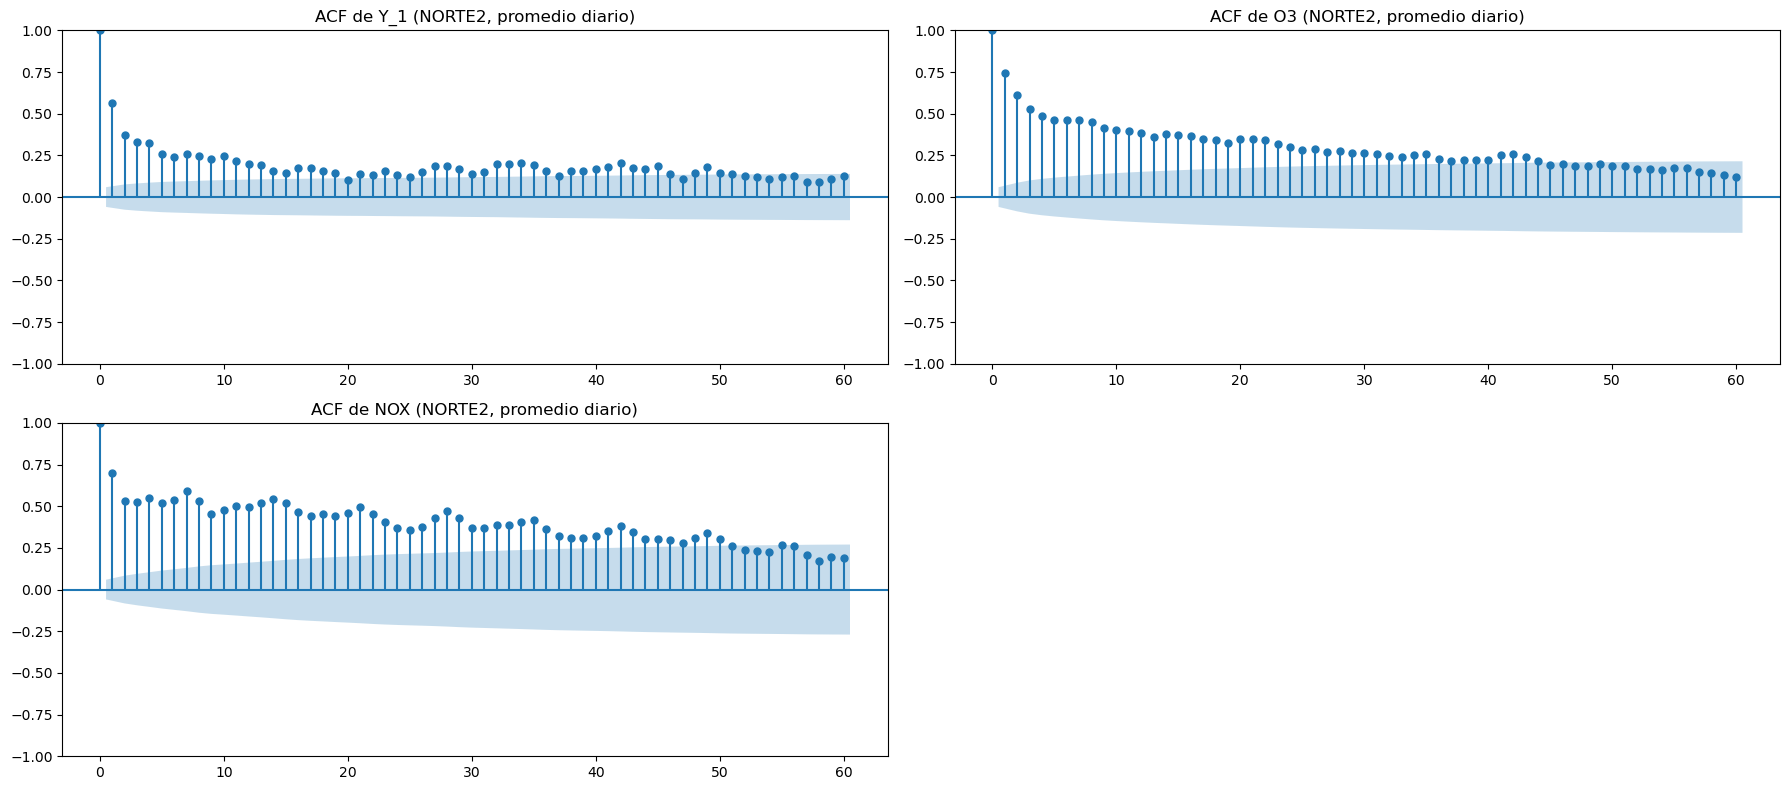

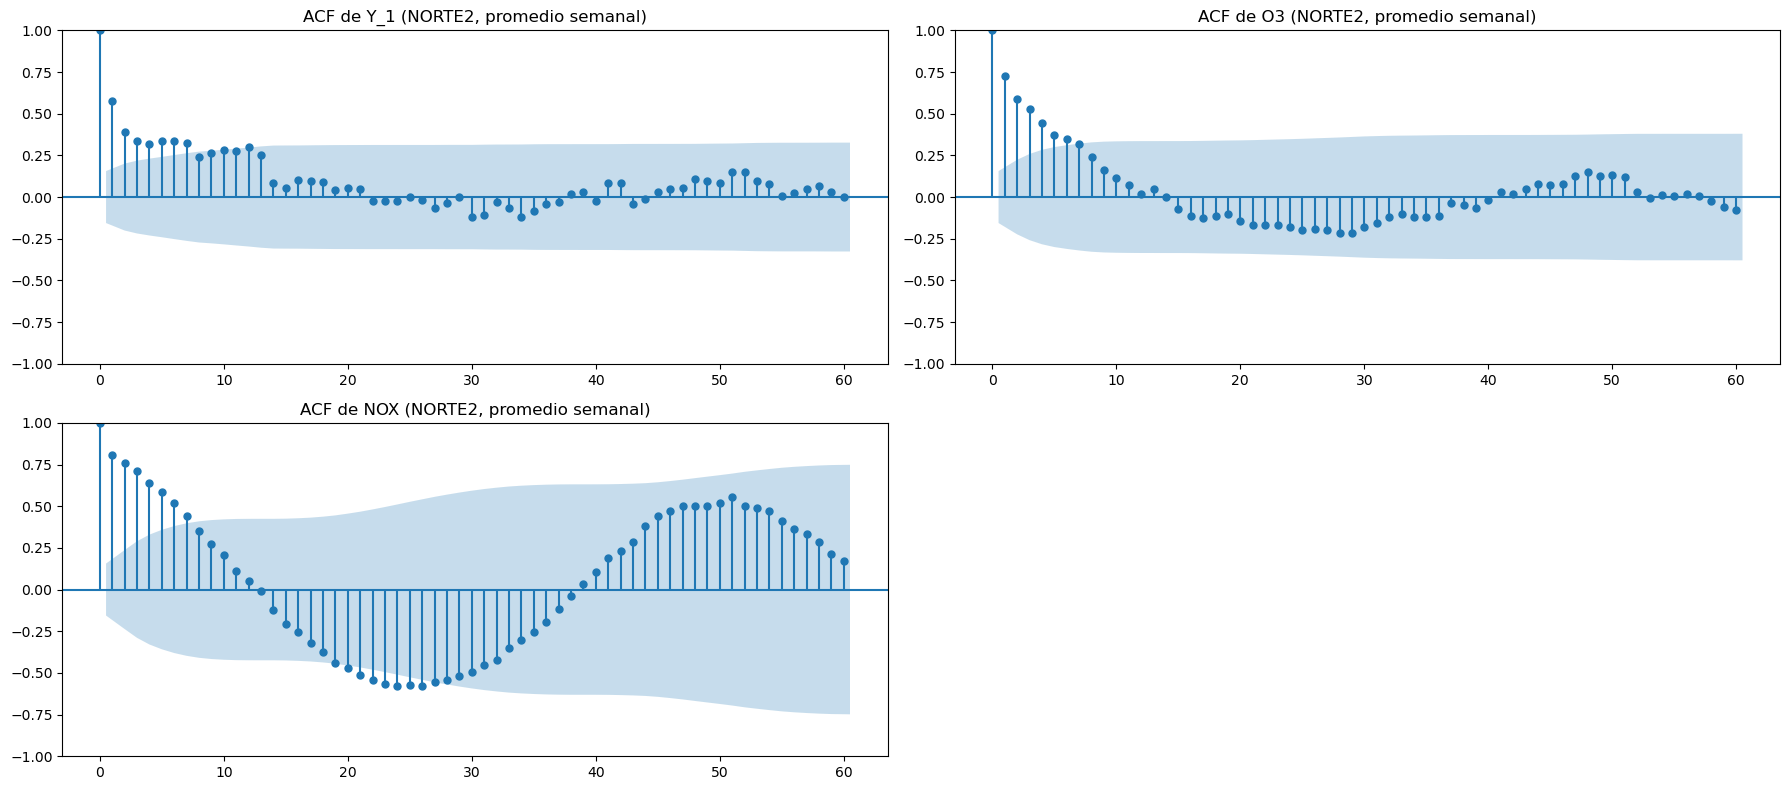

In [121]:
variables_analizar = ["Y_1", "O3", "NOX"]

# --- ACF diario ---
nrows, ncols = 2, 2  # 2 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()  # aplanar para indexado sencillo

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_norte2_diario.columns:
        serie = df_norte2_diario[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)
        ax.set_title(f"ACF de {var} (NORTE2, promedio diario)")
    else:
        ax.set_visible(False)

# Oculta ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# --- ACF semanal ---
nrows, ncols = 2, 2  # 2 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_norte2_semanal.columns:
        serie = df_norte2_semanal[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)  # lags puede ser menor porque hay menos datos semanales
        ax.set_title(f"ACF de {var} (NORTE2, promedio semanal)")
    else:
        ax.set_visible(False)

for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## Paso 4 - Arimax

## Y_1 (PM10, PM2.5, SO2)

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 638.2130067975684
MAE: 0.3642289254857638
RMSE: 0.4298005685038467
R2: -0.43547454906821814
LjungBox_p: 0.8633316748196236
JarqueBera_p: 0.0
best_order: (5, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
0     TOUT  0.186972   0.186972  5.144702e-08
1       RH -0.128689   0.128689  2.900023e-11
4      WSR -0.120464   0.120464  1.008909e-21
3      PRS -0.113098   0.113098  4.165659e-08
2       SR -0.022813   0.022813  4.200927e-01
                               SARIMAX Results                                
Dep. Variable:                    Y_1   No. Observations:                  876
Model:               SARIMAX(5, 1, 5)   Log Likelihood                -303.107
Date:                Sat, 06 Dec 2025   AIC                            638.213
Time:                        20:23:32   BIC                            714.490
Sample:                    01-01-2022   HQIC                           667.400
                         - 05-25-2024             

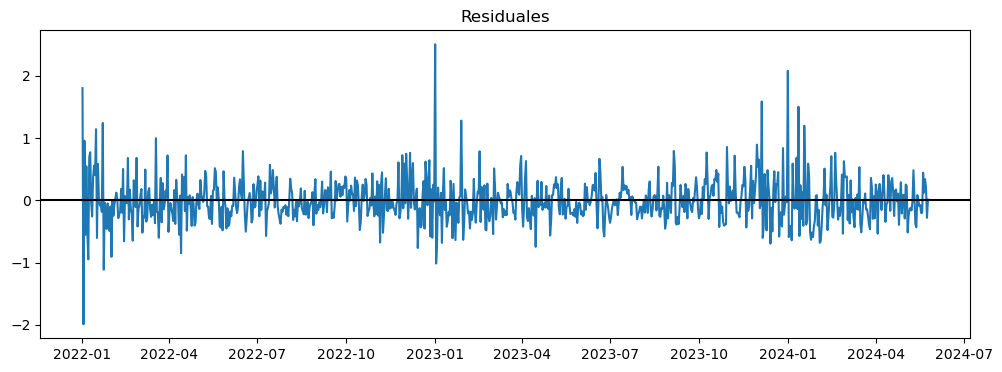

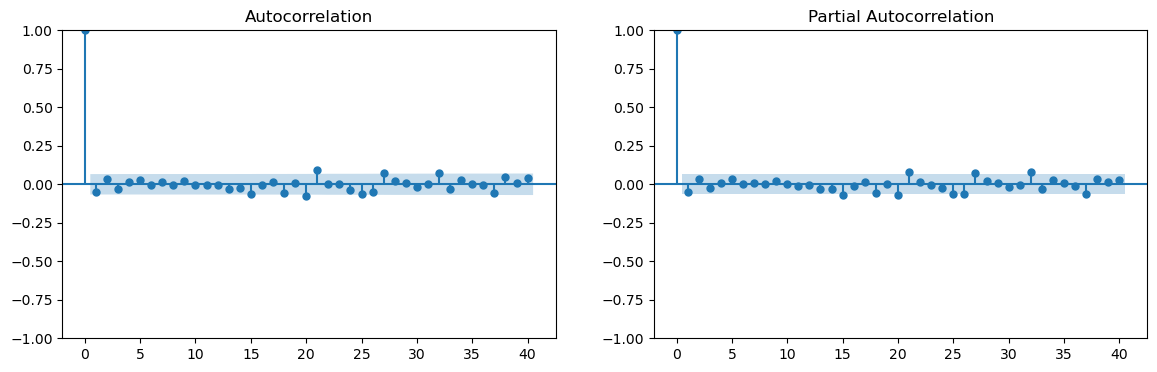

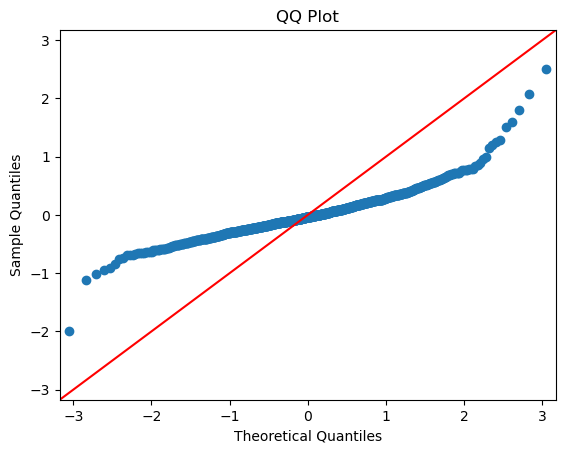

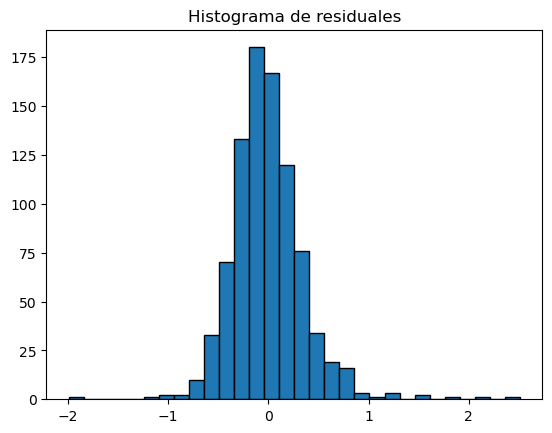

In [122]:
out = fit_best_sarimax(df_norte2_diario, df_norte2_semanal, "Y_1", y_transform=None, inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    y_1_norte2 = best["results"].summary()
    print(y_1_norte2)

plot_diagnostics(best)

## O3

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 5153.039074484645
MAE: 15.595451971360808
RMSE: 16.91987662602351
R2: -3.60012937834996
LjungBox_p: 0.929965135616614
JarqueBera_p: 3.2446882333036406e-12
best_order: (5, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
2       SR  2.788622   2.788622  1.913325e-18
1       RH -2.103749   2.103749  5.871360e-14
0     TOUT -1.075723   1.075723  6.669196e-02
4      WSR -0.824415   0.824415  2.319519e-04
3      PRS  0.472716   0.472716  1.537889e-01
                               SARIMAX Results                                
Dep. Variable:                     O3   No. Observations:                  876
Model:               SARIMAX(5, 1, 5)   Log Likelihood               -2560.520
Date:                Sat, 06 Dec 2025   AIC                           5153.039
Time:                        20:24:15   BIC                           5229.317
Sample:                    01-01-2022   HQIC                          5182.227
                         - 05-25-202

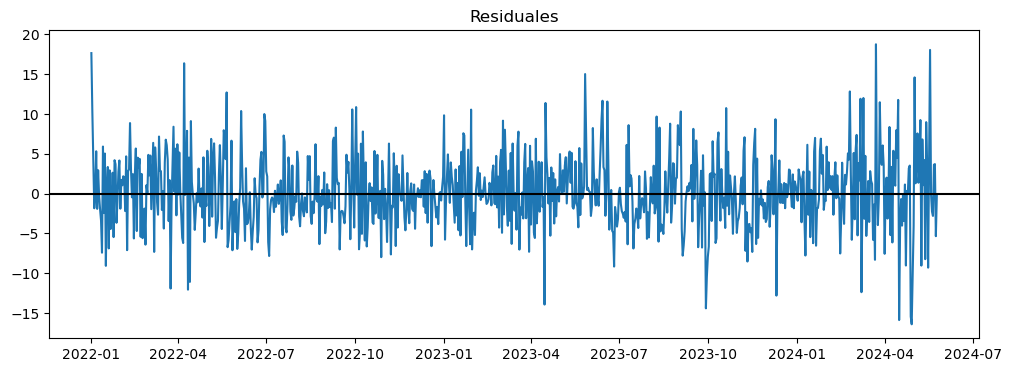

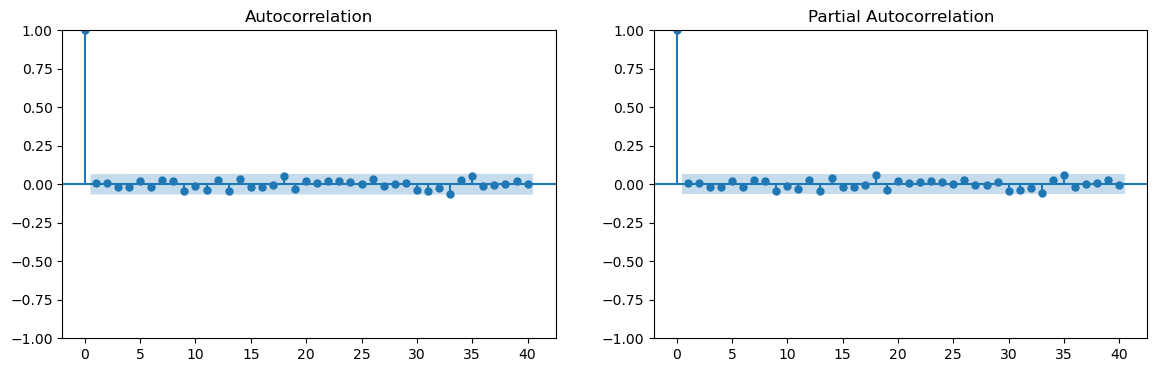

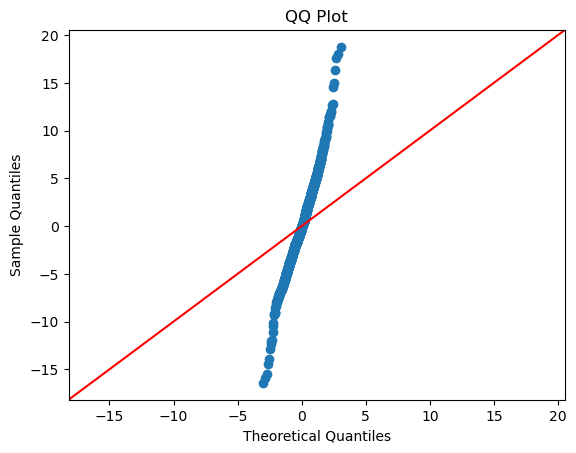

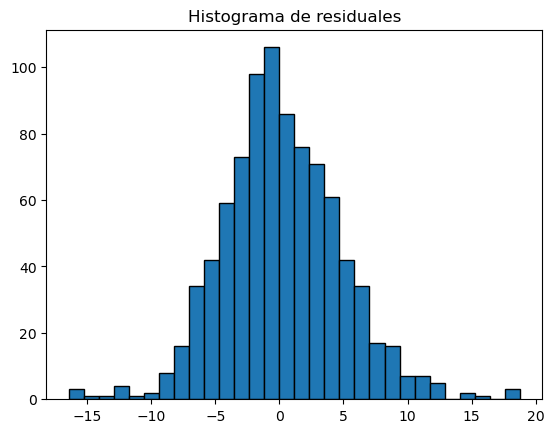

In [123]:
out = fit_best_sarimax(df_norte2_diario, df_norte2_semanal, "O3", y_transform=None, inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    o3_norte2 = best["results"].summary()
    print(o3_norte2)

plot_diagnostics(best)

## NOX

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Semanal
AIC: 793.8290352506692
MAE: 12.268113811954542
RMSE: 17.033032172745997
R2: 0.4914567892095896
LjungBox_p: 0.48597495871033414
JarqueBera_p: 0.0
best_order: (5, 1, 5)
  Variable       Coef  AbsImpact        Pvalue
4      WSR -10.401131  10.401131  2.711620e-22
0     TOUT  -4.661803   4.661803  1.589622e-03
1       RH  -3.005244   3.005244  5.660619e-04
2       SR   0.639789   0.639789  6.493443e-01
3      PRS   0.360186   0.360186  7.051358e-01
                               SARIMAX Results                                
Dep. Variable:                    NOX   No. Observations:                  126
Model:               SARIMAX(5, 1, 5)   Log Likelihood                -380.915
Date:                Sat, 06 Dec 2025   AIC                            793.829
Time:                        20:25:03   BIC                            838.295
Sample:                    01-02-2022   HQIC                           811.885
                         - 05-26-2024       

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


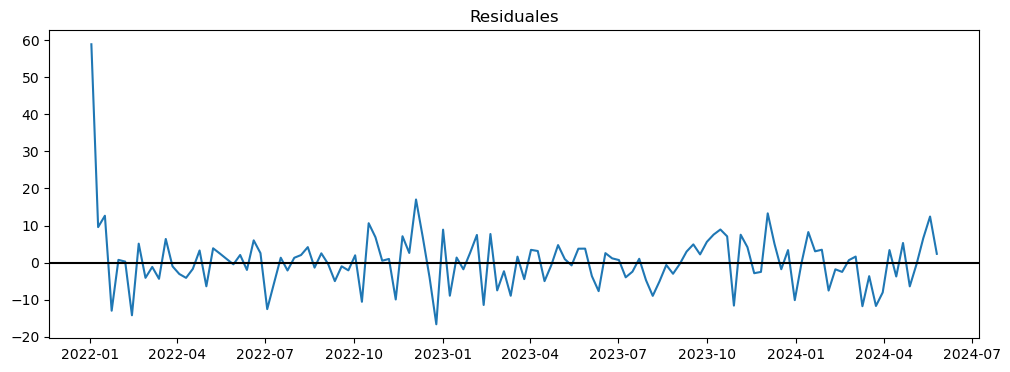

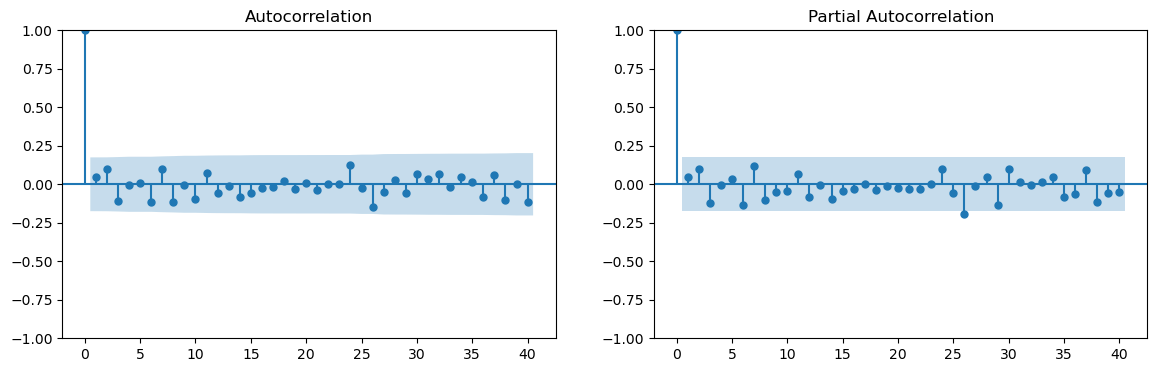

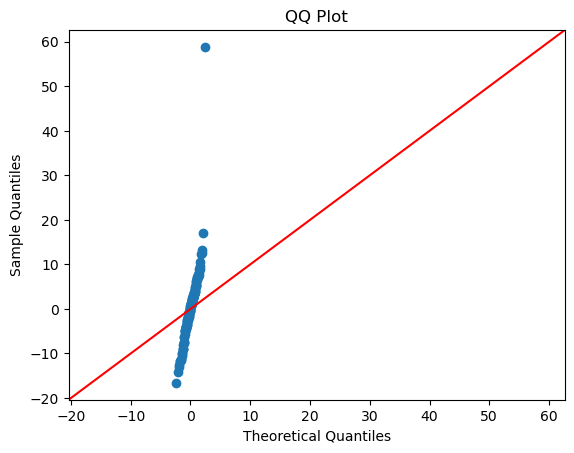

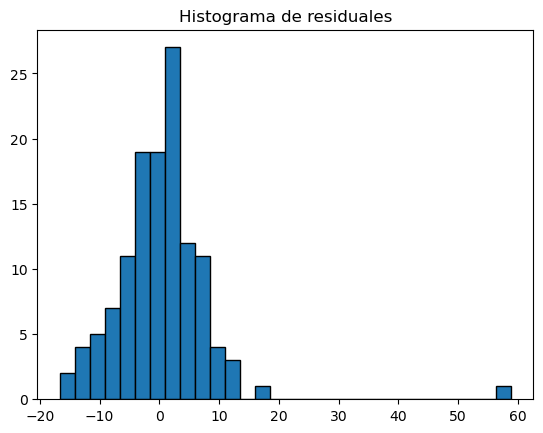

In [124]:
out = fit_best_sarimax(df_norte2_diario, df_norte2_semanal, "NOX", y_transform=None, inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    nox_norte2 = best["results"].summary()
    print(nox_norte2)

plot_diagnostics(best)

# SURESTE3

## data

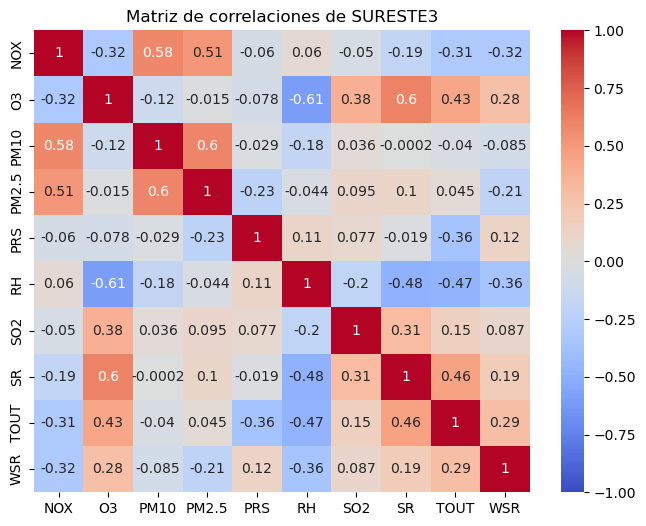

In [32]:
# Cargar datos
sureste3 = pd.read_csv("df_SURESTE3_22_25.csv")
cols_contaminantes = ["PM10", "PM2.5", "O3", "NOX", "SO2"]
datos = sureste3[cols_contaminantes]
corr_matrix = sureste3.drop(columns=['date',"CO"]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de correlaciones de SURESTE3")
plt.show()

## Paso 1 - PCA

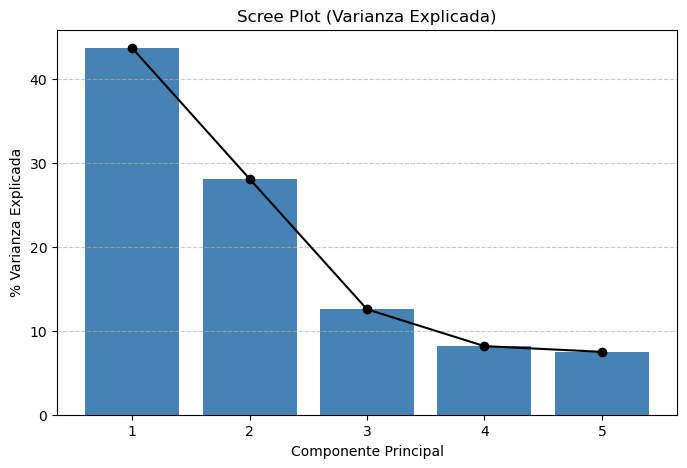

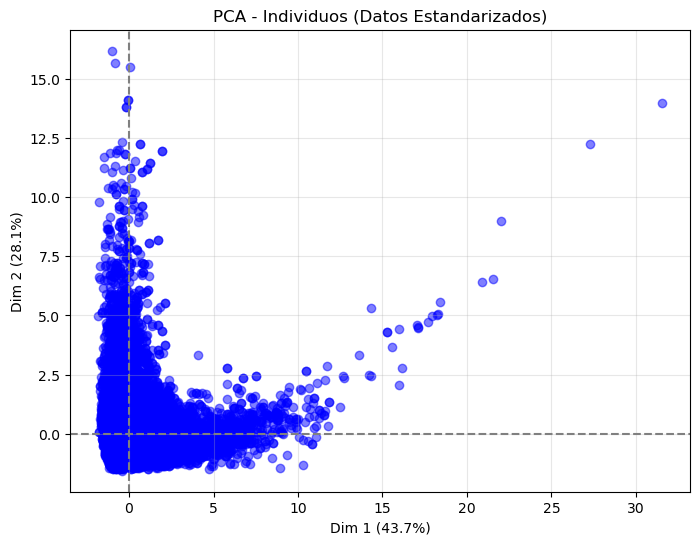

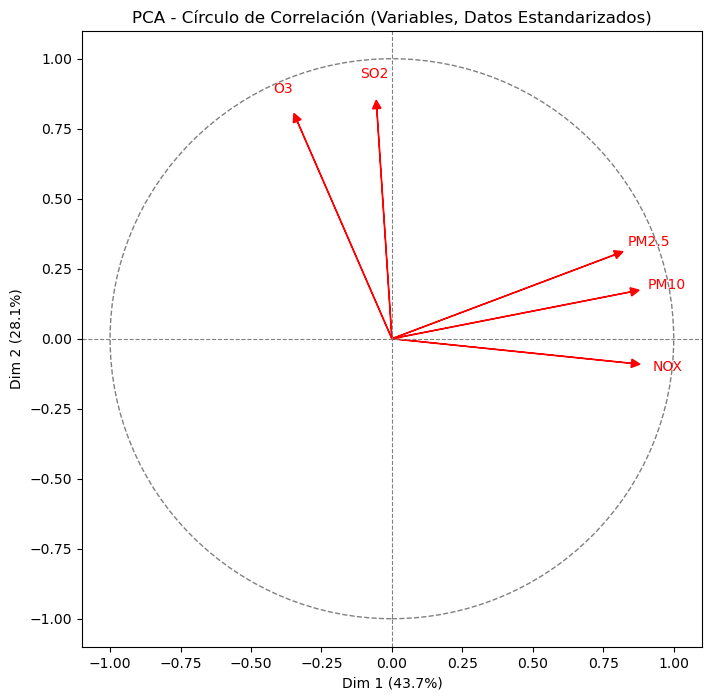

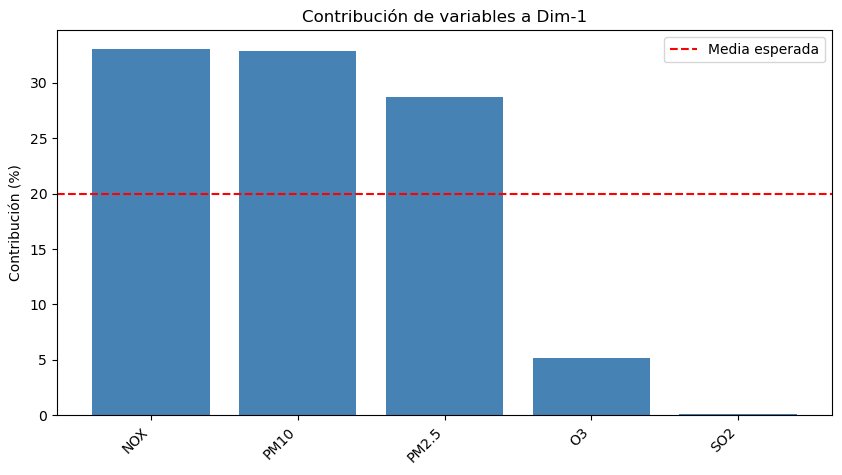

In [126]:
# --- 1. Preparación de datos y estandarización ---
# Estandarizar los datos (media=0, var=1)
scaler = StandardScaler()
datos_std = scaler.fit_transform(datos)

# --- 2. PCA (ahora con datos estandarizados) ---
pca = PCA()
pca_ind = pca.fit_transform(datos_std)

# --- 3. Scree Plot (Varianza explicada) ---
plt.figure(figsize=(8, 5))
varianza_expl = pca.explained_variance_ratio_ * 100
plt.bar(range(1, len(varianza_expl) + 1), varianza_expl, color='steelblue')
plt.plot(range(1, len(varianza_expl) + 1), varianza_expl, marker='o', color='black')
plt.title('Scree Plot (Varianza Explicada)')
plt.xlabel('Componente Principal')
plt.ylabel('% Varianza Explicada')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 4. Gráfica de Individuos ---
plt.figure(figsize=(8, 6))
plt.scatter(pca_ind[:, 0], pca_ind[:, 1], c='blue', alpha=0.5)
plt.xlabel(f'Dim 1 ({varianza_expl[0]:.1f}%)')
plt.ylabel(f'Dim 2 ({varianza_expl[1]:.1f}%)')
plt.title('PCA - Individuos (Datos Estandarizados)')
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. Gráfica de Variables (Círculo de correlación) ---
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
features = datos.columns

plt.figure(figsize=(8, 8))
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], 
              head_width=0.03, head_length=0.03, color='red')
    plt.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature, 
             color='red', ha='center', va='center')

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel(f'Dim 1 ({varianza_expl[0]:.1f}%)')
plt.ylabel(f'Dim 2 ({varianza_expl[1]:.1f}%)')
plt.title('PCA - Círculo de Correlación (Variables, Datos Estandarizados)')
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(False)
plt.show()

# --- 6. Contribución de variables a la Dim-1 ---
contribs = (loadings[:, 0]**2)
contribs = 100 * contribs / contribs.sum()
indices_ordenados = np.argsort(contribs)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(features[indices_ordenados], contribs[indices_ordenados], color='steelblue')
plt.axhline(100/len(features), color='r', linestyle='--', label='Media esperada')
plt.title('Contribución de variables a Dim-1')
plt.ylabel('Contribución (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

## Paso 2 - Agrupación

In [127]:
# Estandarizar columnas relevantes en 'centro'
sureste3["PM10_std"] = (sureste3["PM10"] - sureste3["PM10"].mean()) / sureste3["PM10"].std()
sureste3["PM2.5_std"] = (sureste3["PM2.5"] - sureste3["PM2.5"].mean()) / sureste3["PM2.5"].std()
sureste3["NOX_std"] = (sureste3["NOX"] - sureste3["NOX"].mean()) / sureste3["NOX"].std()
sureste3["SO2_std"] = (sureste3["SO2"] - sureste3["SO2"].mean()) / sureste3["SO2"].std()
centro["O3_std"] = (centro["O3"] - centro["O3"].mean()) / centro["O3"].std()

# Crear los grupos Y en 'centro', incluyendo la fecha de captura
sureste3["Y_1"] = sureste3[["SO2_std", "PM2.5_std", "PM10_std"]].mean(axis=1)

# Incluye la columna "date" en el DataFrame resultado
sureste3_Y = sureste3[["date", "Y_1", "O3","NOX", "TOUT", "RH", "SR", "PRS", "WSR"]]


#diatio
df_sureste3_diario = sureste3_Y.copy()
df_sureste3_diario['date'] = pd.to_datetime(df_sureste3_diario['date'])
df_sureste3_diario = df_sureste3_diario.set_index('date')
df_sureste3_diario = df_sureste3_diario.resample("D").mean()


#semanal
df_sureste3_semanal = sureste3_Y.copy()
df_sureste3_semanal['date'] = pd.to_datetime(df_sureste3_semanal['date'])
df_sureste3_semanal = df_sureste3_semanal.set_index('date')
df_sureste3_semanal = df_sureste3_semanal.resample("W").mean()

In [128]:
df_sureste3_diario.describe().T

,count,mean,std,min,25%,50%,75%,max
Y_1,1096.0,-0.002128,0.431695,-0.724058,-0.315612,-0.086001,0.214464,2.794275
O3,1096.0,25.815418,7.769528,4.937500,20.875000,25.166667,30.083333,61.020833
NOX,1096.0,21.678664,18.681772,4.600000,9.802500,14.975000,25.655208,140.245833
TOUT,1096.0,23.779282,6.316854,1.668333,19.632083,24.966042,28.864687,34.208750
RH,1096.0,60.045198,14.462588,14.708333,50.708333,59.937500,69.635417,92.333333
SR,1096.0,0.148237,0.063850,0.000000,0.100000,0.153750,0.197500,0.295000
PRS,1096.0,727.815903,5.557931,701.034167,722.563542,728.372917,731.947917,739.961250
WSR,1096.0,6.567754,2.968382,1.341667,4.477083,6.170833,8.368229,18.383333


In [129]:
df_sureste3_semanal.describe().T

,count,mean,std,min,25%,50%,75%,max
Y_1,158.0,0.004140,0.291695,-0.550015,-0.190654,-0.035677,0.206413,0.780790
O3,158.0,25.778789,6.180847,9.156627,22.104167,25.589286,28.598214,44.285714
NOX,158.0,21.847053,14.566100,6.668155,10.540253,16.808036,28.928423,69.467262
TOUT,158.0,23.756012,5.777014,8.346131,19.464539,24.810000,28.840372,32.891369
RH,158.0,59.834939,10.797175,25.956071,51.889881,59.532738,68.465030,87.839286
SR,158.0,0.148101,0.053108,0.030417,0.106949,0.151786,0.188750,0.277083
PRS,158.0,727.833809,4.864159,720.210714,722.583333,729.081399,731.531741,737.605417
WSR,158.0,6.583192,2.419741,1.944048,5.065402,6.297917,7.962277,15.580952


## Paso 3 - ACF

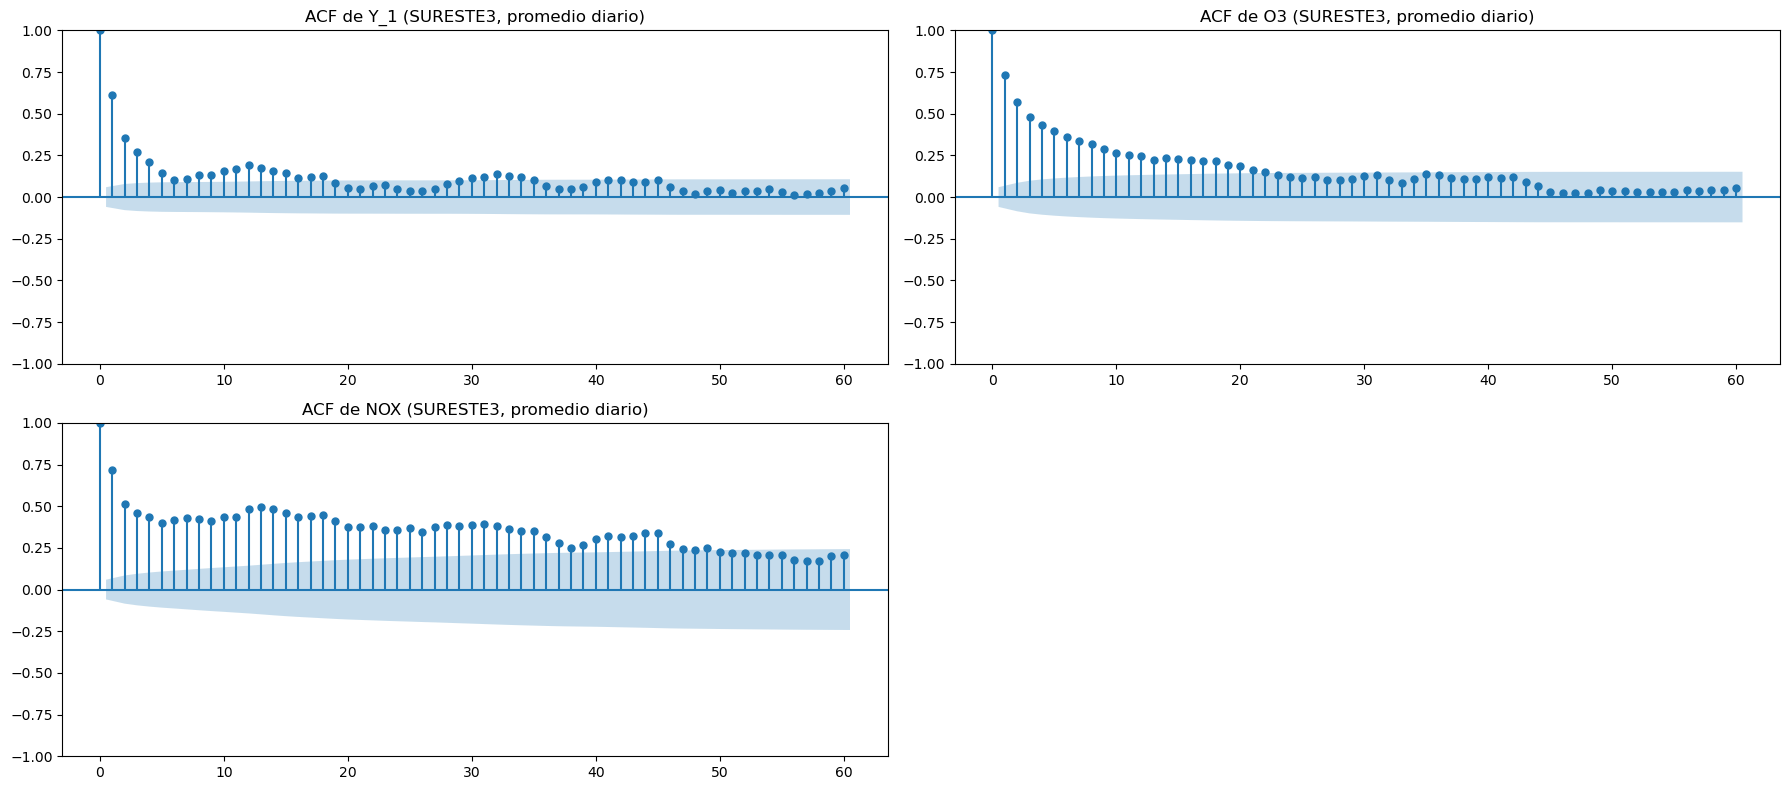

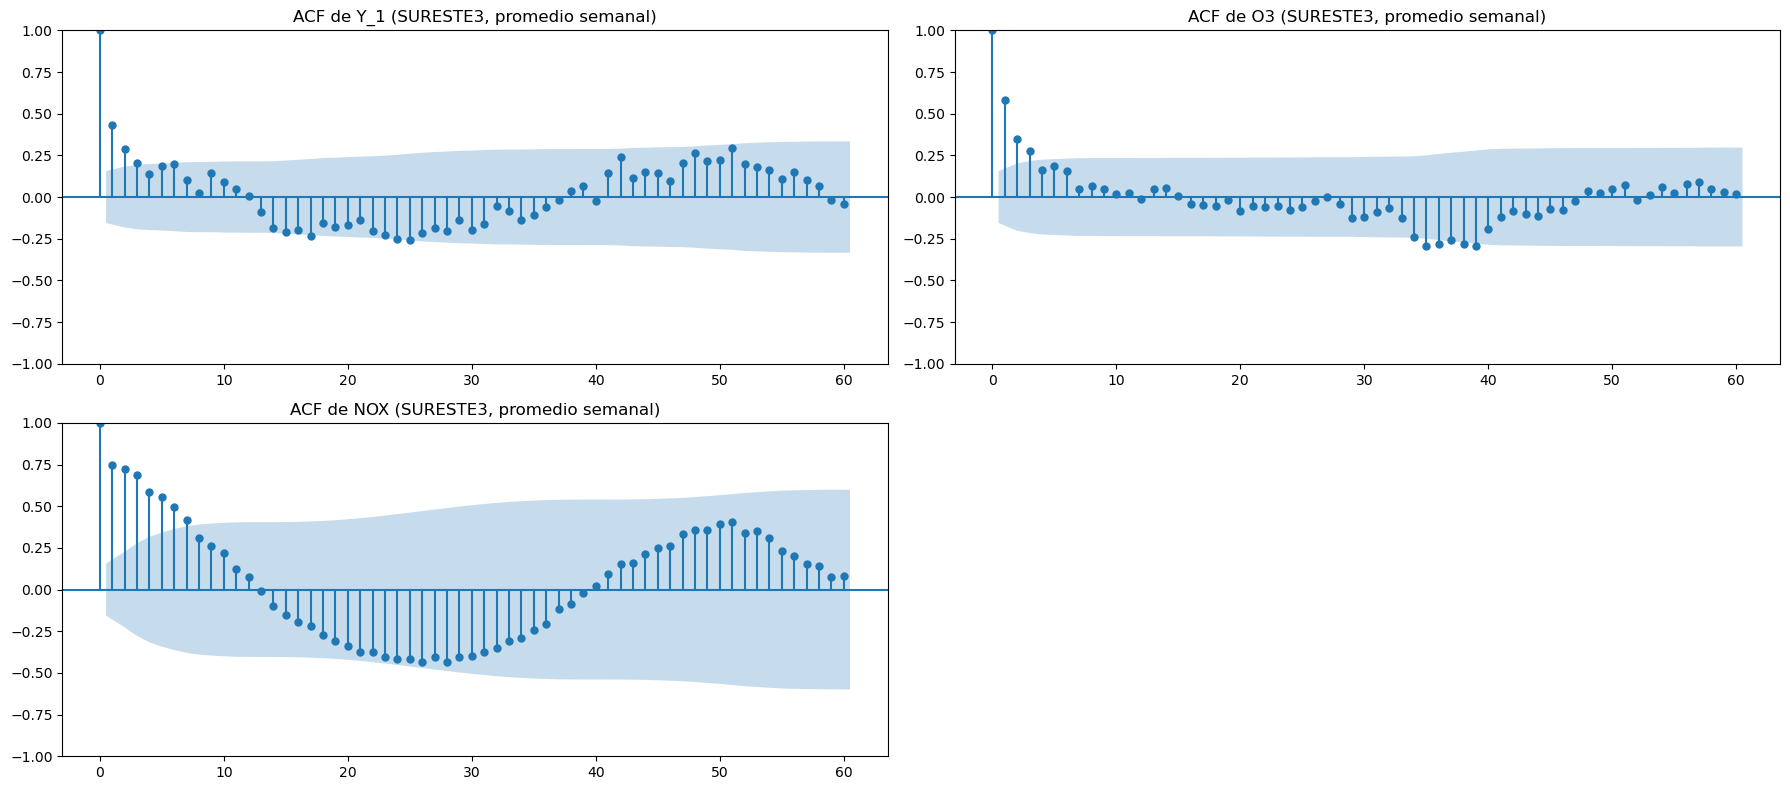

In [130]:
variables_analizar = ["Y_1", "O3", "NOX"]

# --- ACF diario ---
nrows, ncols = 2, 2  # 2 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()  # aplanar para indexado sencillo

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_sureste3_diario.columns:
        serie = df_sureste3_diario[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)
        ax.set_title(f"ACF de {var} (SURESTE3, promedio diario)")
    else:
        ax.set_visible(False)

# Oculta ejes extra si hay menos variables
for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# --- ACF semanal ---
nrows, ncols = 2, 2  # 2 filas x 2 columnas
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8))
axes = axes.flatten()

for i, var in enumerate(variables_analizar):
    ax = axes[i]
    if var in df_sureste3_semanal.columns:
        serie = df_sureste3_semanal[var].dropna()
        plot_acf(serie, ax=ax, lags=60, alpha=0.05)  # lags puede ser menor porque hay menos datos semanales
        ax.set_title(f"ACF de {var} (SURESTE3, promedio semanal)")
    else:
        ax.set_visible(False)

for j in range(len(variables_analizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Paso 4 - Arimax

### Y_1 (PM10, PM2.5, SO2)

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Semanal
AIC: -29.040570068507535
MAE: 0.22903816983929173
RMSE: 0.2863981090201415
R2: 0.06811924181738127
LjungBox_p: 0.790175509432174
JarqueBera_p: 0.08282486555972543
best_order: (1, 0, 1)
  Variable      Coef  AbsImpact    Pvalue
4      WSR -0.150086   0.150086  0.000176
1       RH -0.109052   0.109052  0.000503
0     TOUT  0.095968   0.095968  0.087735
2       SR  0.044743   0.044743  0.427811
3      PRS -0.036366   0.036366  0.539489
                               SARIMAX Results                                
Dep. Variable:                    Y_1   No. Observations:                  126
Model:               SARIMAX(1, 0, 1)   Log Likelihood                  22.520
Date:                Sat, 06 Dec 2025   AIC                            -29.041
Time:                        20:26:13   BIC                             -6.478
Sample:                    01-02-2022   HQIC                           -19.875
                         - 05-26-2024                   

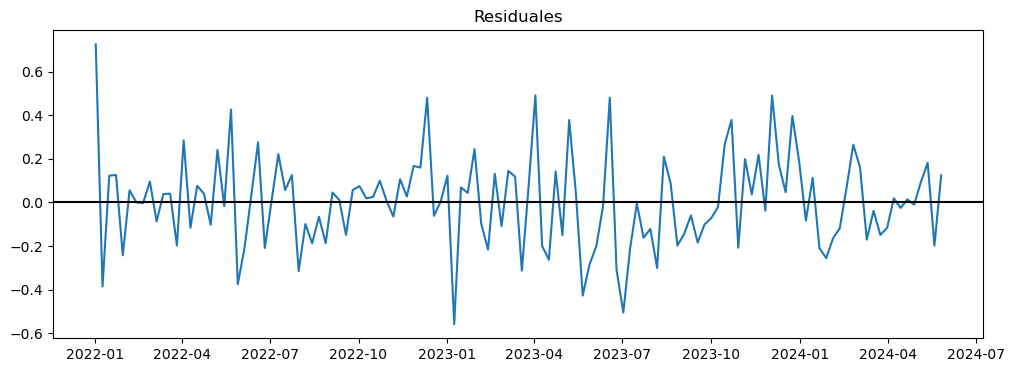

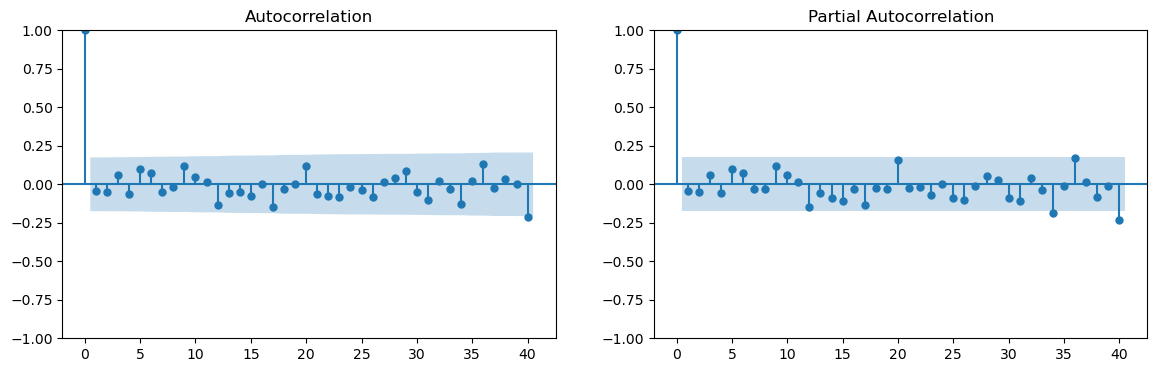

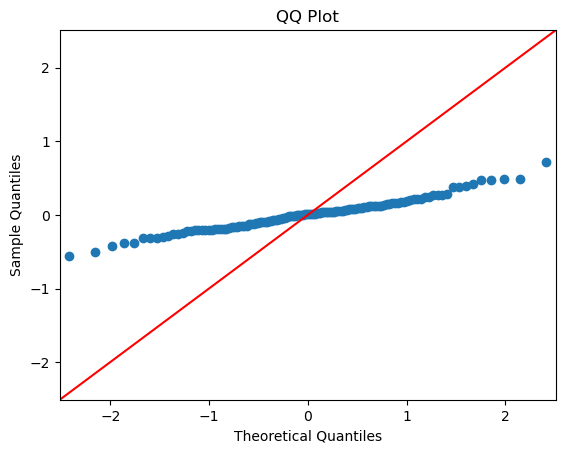

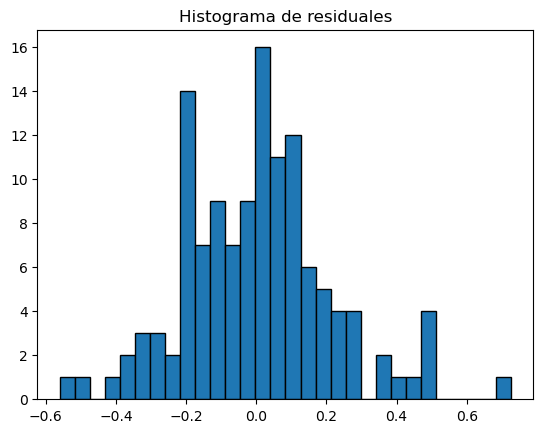

In [131]:
out = fit_best_sarimax(df_sureste3_diario, df_sureste3_semanal, "Y_1", y_transform=None, inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    y_1_sureste3 = best["results"].summary()
    print(y_1_sureste3)

plot_diagnostics(best)

### O3

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 5187.747371018265
MAE: 7.651862957607974
RMSE: 9.22233737791019
R2: -0.9674610416466463
LjungBox_p: 0.8764297669067116
JarqueBera_p: 5.47846572130684e-25
best_order: (3, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
1       RH -2.733135   2.733135  1.390787e-28
2       SR  1.587412   1.587412  3.576285e-08
0     TOUT -1.182289   1.182289  3.956440e-03
4      WSR -0.414792   0.414792  1.062900e-01
3      PRS -0.211663   0.211663  2.962747e-01
                               SARIMAX Results                                
Dep. Variable:                     O3   No. Observations:                  876
Model:               SARIMAX(3, 1, 5)   Log Likelihood               -2579.874
Date:                Sat, 06 Dec 2025   AIC                           5187.747
Time:                        20:26:58   BIC                           5254.490
Sample:                    01-01-2022   HQIC                          5213.286
                         - 05-25-2024

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


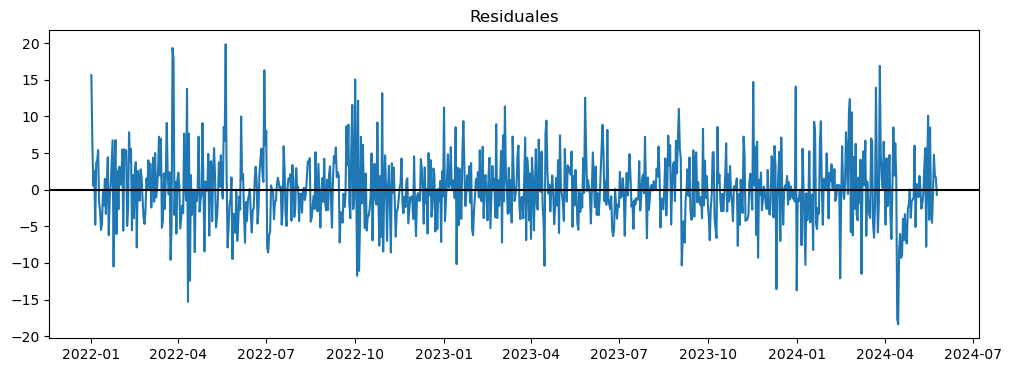

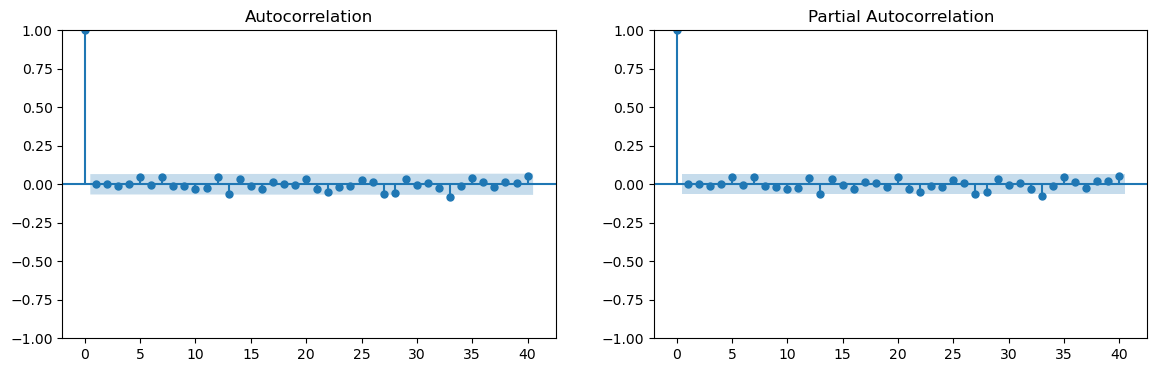

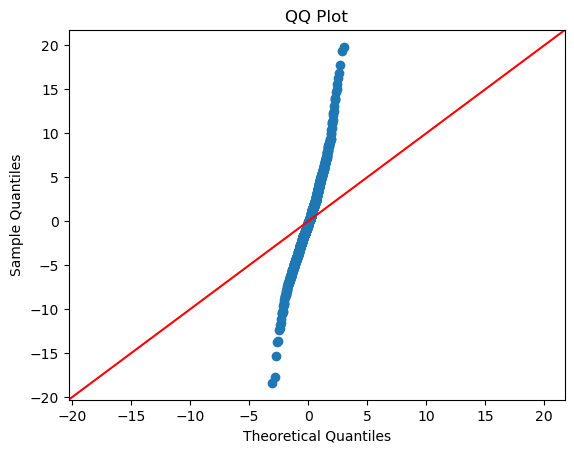

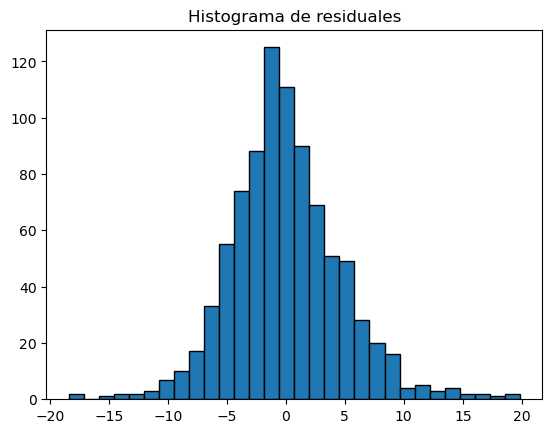

In [132]:
out = fit_best_sarimax(df_sureste3_diario, df_sureste3_semanal, "O3", y_transform=None, inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    o3_sureste3 = best["results"].summary()
    print(o3_sureste3)

plot_diagnostics(best)

### NOX

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Semanal
AIC: 818.246952795531
MAE: 7.498297594140026
RMSE: 10.355711421934538
R2: 0.1761423562315022
LjungBox_p: 0.9969377401218921
JarqueBera_p: 3.010508102664524e-11
best_order: (1, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
4      WSR -8.026452   8.026452  2.021662e-10
3      PRS -4.493806   4.493806  1.923001e-03
1       RH -4.028926   4.028926  1.327790e-03
0     TOUT -3.857538   3.857538  7.262107e-02
2       SR -0.685325   0.685325  7.698219e-01
                               SARIMAX Results                                
Dep. Variable:                    NOX   No. Observations:                  126
Model:               SARIMAX(1, 1, 5)   Log Likelihood                -397.123
Date:                Sat, 06 Dec 2025   AIC                            818.247
Time:                        20:27:42   BIC                            851.596
Sample:                    01-02-2022   HQIC                           831.789
                         - 05-26-20

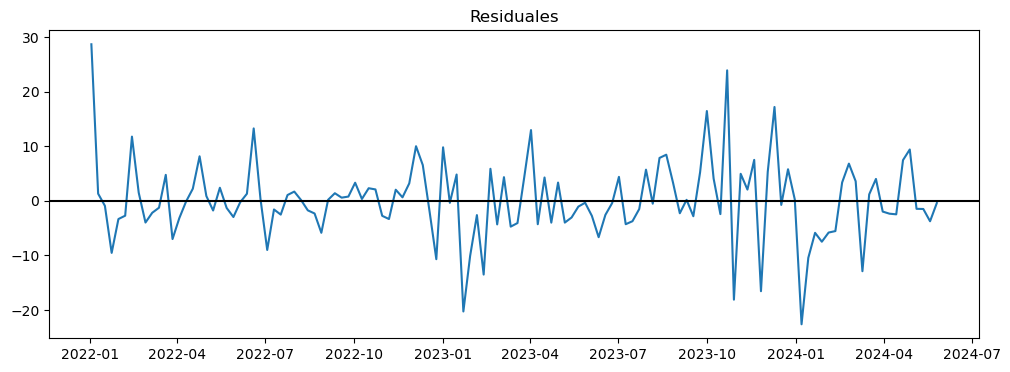

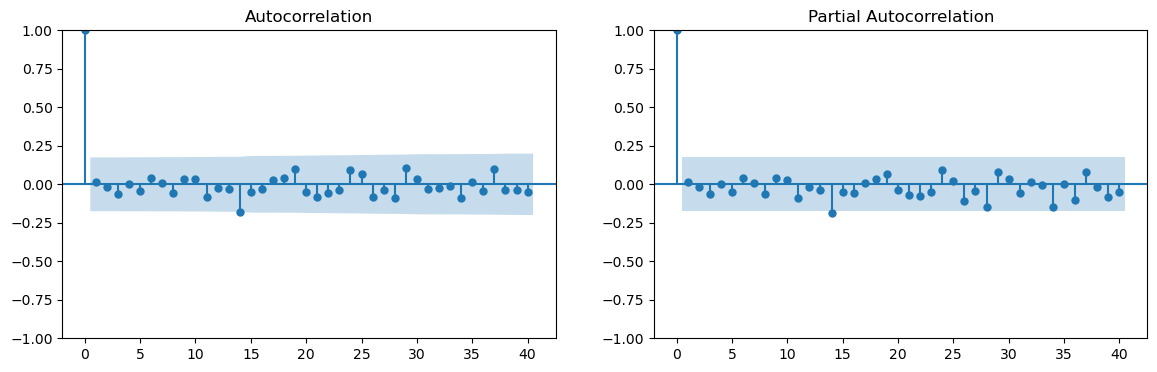

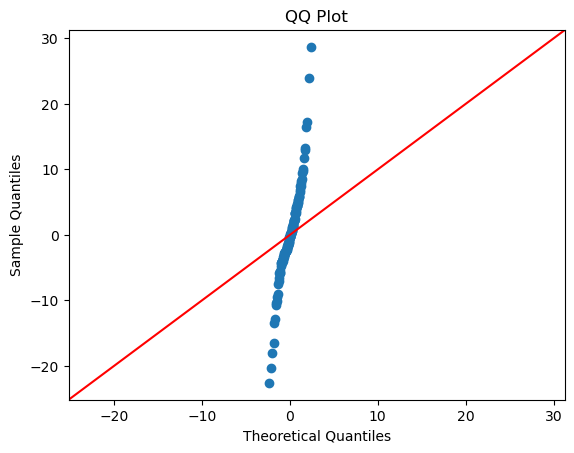

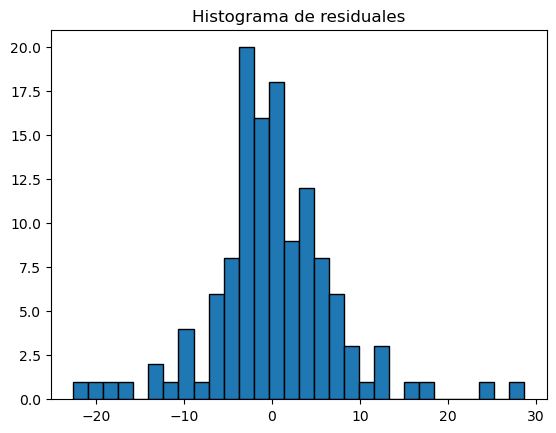

In [133]:
out = fit_best_sarimax(df_sureste3_diario, df_sureste3_semanal, "NOX", y_transform=None, inverse_transform=None)


for best in [out["best"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    nox_sureste3 = best["results"].summary()
    print(nox_sureste3)

plot_diagnostics(best)